In [72]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

import tifffile
from skimage.measure import regionprops_table
import random
import umap
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
#### xy pixel size = 0.1893014, z pixel size = 0.7996567
XY_UM = 0.1893014
Z_UM = 0.7996567

directory = Path(r"z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results")
folders = []
for folder in directory.iterdir():
    if folder.is_dir():
        folders.append(folder)
folders_to_read = [f for f in folders if "noamp" not in f.name and "noim" not in f.name]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")

# Read in the Data (Skip this, already loaded)
- You can now skip this and just read in the data directly from the csv 

In [73]:
def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    props = props.rename(columns={
        "centroid-0": "nucleus_centroid_z",
        "centroid-1": "nucleus_centroid_y",
        "centroid-2": "nucleus_centroid_x",
    })
    zmax, ymax, xmax = mask.shape
    return props, (int(xmax), int(ymax), int(zmax))

In [ ]:
def check_one(folder: Path):
    """ Sanity check that we can use the NucleiLocation.csv data rather than reading in the segmentation mask each time
    Values of 0 mean the mask matches the csv data
    """
    seg_path = next(iter(folder.glob("*seg_mask.tif*")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)
    if seg_path is None or not xyz_path.exists():
        print("File Missing")
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs().round(3)
    dy = (m["nucleus_centroid_y"] - m["y"]).abs().round(3)
    dz = (m["nucleus_centroid_z"] - m["z"]).abs().round(3)
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
    }

test = folders_to_read[1]
report = pd.DataFrame([check_one(test)])


In [ ]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"

def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    zmax, ymax, xmax = tuple(s for s in shape if s > 1)  # drop singleton axes
    return int(xmax), int(ymax), int(zmax)

all_tables = []

for folder in folders_to_read:
    print(folder)
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask.tif")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue
    if not count_csv.exists():
        print(f"[SKIP - no count_table.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei, extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


# Read Gene Counts (Run from Here)
- iterate through folders and extract counts
- define cells as endothelilal/fibroblast/unknown
- restrict to cells with spots, and with gene IDs that occur in >3 cells

In [15]:
combined = pd.read_csv(output_dir / "all_nuclei.csv")

In [16]:
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]

# Lineage from marker PRESENCE: ne / nf = how many endo / fibro markers a cell detects.
# Confidence is purity-based - a "confident" cell expresses one lineage's markers and
# NONE of the other's. Because the confident sets contain zero markers of the opposite
# lineage, a cross-lineage pair (e.g. COL1A1 inside endothelial) can never appear there,
# which is what removes the circular artefact without needing leave-two-out downstream.
endo_on = (combined[endo_genes].fillna(0) > 0).sum(axis=1)
fibro_on = (combined[fibro_genes].fillna(0) > 0).sum(axis=1)
combined["n_endo_markers"] = endo_on
combined["n_fibro_markers"] = fibro_on
combined["endothelial_score"] = endo_on / len(endo_genes)
combined["fibroblast_score"] = fibro_on / len(fibro_genes)

def lineage_tier(ne, nf):
    """Order cells along the endothelial<->fibroblast axis into 5 confidence tiers.
    Confident = at least 2 of its own markers and none of the other lineage's."""
    if ne >= 2 and nf == 0:
        return "endothelial (confident)"
    if nf >= 2 and ne == 0:
        return "fibroblast (confident)"
    if ne > nf:
        return "endothelial (tentative)"
    if nf > ne:
        return "fibroblast (tentative)"
    return "unknown"                     # tie, incl. no markers at all

combined["lineage_tier"] = [lineage_tier(ne, nf) for ne, nf in zip(endo_on, fibro_on)]
combined["cell_type"] = combined["lineage_tier"].str.split().str[0]   # endothelial/fibroblast/unknown
combined["confident"] = combined["lineage_tier"].str.contains("confident")

TIER_ORDER = ["endothelial (confident)", "endothelial (tentative)", "unknown",
              "fibroblast (tentative)", "fibroblast (confident)"]
print(combined["lineage_tier"].value_counts().reindex(TIER_ORDER))


lineage_tier
endothelial (confident)    4163
endothelial (tentative)    3225
unknown                    4927
fibroblast (tentative)      441
fibroblast (confident)      291
Name: count, dtype: int64


### Do clustering and scoring give the same lineages?

The block above assigns each cell to a lineage by **marker scoring** (endothelial /
fibroblast / unknown, plus a confident-vs-tentative tier from marker purity). Below
`cluster_marker_types` instead **clusters** cells on their endothelial + fibroblast
marker counts (log1p, z-scored) with KMeans (`K=2`) and names each cluster from its own
mean marker profile. We then compare the two labellings on the **committed** cells
(those scoring calls endothelial or fibroblast) via a confusion table, exact agreement
and the Adjusted Rand Index. If they largely agree, we can justify using the simpler,
reproducible **scoring** definition for the rest of the analysis.


In [17]:
# ---- Unsupervised (marker-based) cell typing ----------------------------------
# Instead of hand-tuning the endothelial/fibroblast/unknown rule, cluster cells on
# their marker expression and let each cluster's mean profile name it. Uses RAW counts,
# so run this before the binarisation cell below.


def cluster_marker_types(data, endo_genes, fibro_genes, K=None,
                         k_range=range(2, 9), random_state=0):
    """Cluster cells on marker expression (log1p + z-scored) and name each cluster from
    its mean marker programme (below-average for both programmes -> 'unknown').

    K : number of clusters. If None, chosen by the best average silhouette over
        `k_range`. Pass e.g. K=3 to force one cluster per target identity.
    Returns (cluster_labels, cluster_to_type, overview_df).
    """
    marker_genes = endo_genes + fibro_genes
    marker_z = StandardScaler().fit_transform(
        np.log1p(data[marker_genes].fillna(0).astype(float).to_numpy()))

    if K is None:
        sil = {}
        for k in k_range:
            lab = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit_predict(marker_z)
            sil[k] = silhouette_score(marker_z, lab,
                                      sample_size=min(10000, len(marker_z)),
                                      random_state=random_state)
        K = max(sil, key=sil.get)
        print("Silhouette by K: " + ", ".join(f"{k}:{s:.3f}" for k, s in sil.items()))
    print(f"Using K = {K}")

    clusters = KMeans(n_clusters=K, n_init=10, random_state=random_state).fit_predict(marker_z)
    prof_z = pd.DataFrame(marker_z, columns=marker_genes)
    prof_z["cluster"] = clusters
    prof_z = prof_z.groupby("cluster").mean()
    endo_program = prof_z[endo_genes].mean(axis=1)
    fibro_program = prof_z[fibro_genes].mean(axis=1)

    def name_cluster(c):
        e, f = endo_program[c], fibro_program[c]
        if e < 0 and f < 0:        # below-average for BOTH programmes -> no clear identity
            return "unknown"
        return "endothelial" if e > f else "fibroblast"

    cluster_to_type = {c: name_cluster(c) for c in prof_z.index}
    overview = pd.DataFrame({
        "n_cells": pd.Series(clusters).value_counts().sort_index(),
        "endo_program_z": endo_program.round(2),
        "fibro_program_z": fibro_program.round(2),
        "assigned": pd.Series(cluster_to_type),
    })
    return clusters, cluster_to_type, overview


# Cross-check the scoring lineages with K=2 marker clustering (endothelial vs fibroblast).
marker_clusters, cluster_to_type, overview = cluster_marker_types(
    combined, endo_genes, fibro_genes, K=2)
combined["marker_cluster"] = marker_clusters
combined["cell_type_clustering"] = combined["marker_cluster"].map(cluster_to_type)
display(overview)
print(combined["cell_type_clustering"].value_counts())

Using K = 2


,n_cells,endo_program_z,fibro_program_z,assigned
0,602,-0.33,2.67,fibroblast
1,12445,0.02,-0.13,endothelial


cell_type_clustering
endothelial    12445
fibroblast       602
Name: count, dtype: int64


Confusion table (rows = scoring, cols = clustering), committed cells only:


cell_type_clustering,endothelial,fibroblast
cell_type,,
endothelial,7346,42
fibroblast,210,522


Exact-label agreement (committed cells): 96.9%
Adjusted Rand Index (partition agreement): 0.760


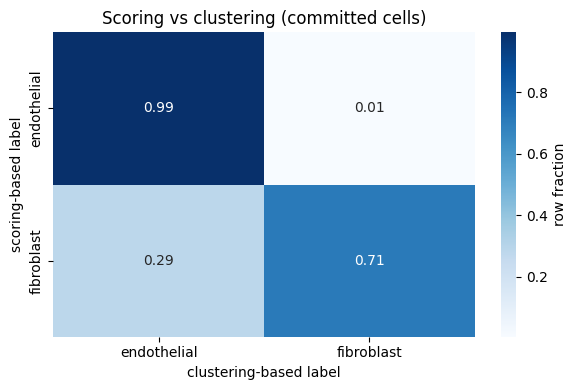

In [18]:
# ---- Scoring vs clustering: do the two lineage definitions agree? ----
# Compare on the COMMITTED cells (scoring calls them endothelial or fibroblast); the
# scoring 'unknown' bucket has no clustering counterpart so it is excluded here.
committed = combined[combined["cell_type"].isin(["endothelial", "fibroblast"])]
xtab = pd.crosstab(committed["cell_type"], committed["cell_type_clustering"])
print("Confusion table (rows = scoring, cols = clustering), committed cells only:")
display(xtab)

agreement = (committed["cell_type"] == committed["cell_type_clustering"]).mean()
ari = adjusted_rand_score(committed["cell_type"], committed["cell_type_clustering"])
print(f"Exact-label agreement (committed cells): {100 * agreement:.1f}%")
print(f"Adjusted Rand Index (partition agreement): {ari:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pd.crosstab(committed["cell_type"], committed["cell_type_clustering"],
                        normalize="index"),
            annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar_kws={"label": "row fraction"})
ax.set_title("Scoring vs clustering (committed cells)")
ax.set_xlabel("clustering-based label"); ax.set_ylabel("scoring-based label")
plt.tight_layout(); plt.show()


In [19]:
# Tidy matrix: genes are either on (1+ counts) or off (0 counts). Drop FP readouts and create a readable gene state for on genes (e.g. 1_4_12)
metadata_cols = {
    "name", "source_folder", "nucleus",
    "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z", 
    "Xmax", "Ymax", "Zmax", "cell_type", "endothelial_score", "fibroblast_score",
    "n_endo_markers", "n_fibro_markers", "lineage_tier", "confident", "had_reads",
    "marker_cluster", "cell_type_clustering",  # unsupervised cell-typing outputs
    "state_code", "binary_state",  # derived label columns, not genes
}
gene_columns = [c for c in combined.columns if c not in metadata_cols]
fp_columns = [c for c in gene_columns if c.startswith("FP")]
true_gene_columns = [c for c in gene_columns if not c.startswith("FP")]

combined[true_gene_columns] = (combined[true_gene_columns].fillna(0).astype(float) > 0).astype(int)
combined["state_code"] = combined[true_gene_columns].apply(
    lambda row: "_".join(str(i + 1) for i, value in enumerate(row) if value == 1), axis=1,
).replace("", "0")  # all-negative cells get the code "0"
true_gene_dictionary = {c: i for i, c in enumerate(true_gene_columns)}

# # binary_state: one digit per gene in column order, e.g. "100100000001000000"
combined["binary_state"] = combined[true_gene_columns].astype(str).agg("".join, axis=1)


In [20]:
# Keep ALL cells and ALL states (no rare-state filtering). The all-0-read cells carry no
# transcripts, so for the full-population pairwise we split them into endothelial /
# fibroblast at the ratio of the CONFIDENT cells (seeded, reproducible). They stay
# flagged by had_reads=False and confident=False, so they never enter the lineage-
# specific (confident-only) analysis.
combined["had_reads"] = combined[true_gene_columns].sum(axis=1) > 0

conf_endo = int((combined["lineage_tier"] == "endothelial (confident)").sum())
conf_fibro = int((combined["lineage_tier"] == "fibroblast (confident)").sum())
p_fibro = conf_fibro / (conf_endo + conf_fibro)

zero_idx = combined.index[~combined["had_reads"]].to_numpy().copy()
rng = np.random.default_rng(0)
rng.shuffle(zero_idx)
n_fibro = int(round(p_fibro * len(zero_idx)))
combined.loc[zero_idx[:n_fibro], "cell_type"] = "fibroblast"
combined.loc[zero_idx[n_fibro:], "cell_type"] = "endothelial"
print(f"Confident ratio endo:fibro = {conf_endo}:{conf_fibro} "
      f"-> {len(zero_idx):,} all-0 cells split as "
      f"{len(zero_idx) - n_fibro:,} endothelial / {n_fibro:,} fibroblast")


Confident ratio endo:fibro = 4163:291 -> 3,575 all-0 cells split as 3,341 endothelial / 234 fibroblast


In [21]:
n_total = len(combined)
state_counts = combined.loc[combined["had_reads"], "state_code"].value_counts()
print(f"All cells:                     {n_total:,}")
print(f"Cells with >=1 transcript:     {combined['had_reads'].sum():,} "
      f"({100 * combined['had_reads'].mean():.1f}%)")
print(f"Unique expressed states:       {state_counts.size:,} (all kept, rare states retained)")
print(f"Singleton states (1 cell):     {(state_counts == 1).sum():,}")

print("\nConfident cells per lineage (used for the lineage-specific pairwise):")
print(combined.loc[combined["confident"], "cell_type"].value_counts())


All cells:                     13,047
Cells with >=1 transcript:     9,472 (72.6%)
Unique expressed states:       1,555 (all kept, rare states retained)
Singleton states (1 cell):     908

Confident cells per lineage (used for the lineage-specific pairwise):
cell_type
endothelial    4163
fibroblast      291
Name: count, dtype: int64


# Spatial & genetic subpopulation analysis

From here the lineage is the **scoring** definition (`cell_type` + `confident`). The
working frame **`df`** keeps **every cell and every state** (no rare-state filtering);
the all-0-read cells have been split into lineages at the confident ratio so they can
join the full-population statistics.

**Coordinates** are converted to microns using the acquisition pixel sizes
(xy = 0.1893014 um, z = 0.7996567 um), and every spatial calculation is performed
*within each image* (`source_folder`) so neighbourhoods never span different images.

**Roadmap**
1. **Pairwise gene interactions** - the full population (all cells, incl. all-0 and
   unknown), then endothelial and fibroblast separately using **confident cells only**.
2. **Gene states -> cell states** - hierarchical clustering, UMAP, Leiden, and a
   Bernoulli mixture model (Section 2, left for later).
3. **Neighbourhood analysis** - per-cell micro-environment, then niches.
4. **Graph-based approaches** - spatial cell graph and gene-state graph.

## 0. Setup - analysis frame & physical coordinates



In [22]:
# Working frame: EVERY cell, scoring lineage definition (cell_type / confident / tier).
df = combined.copy().reset_index(drop=True)
df

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,endothelial_score,fibroblast_score,lineage_tier,cell_type,confident,marker_cluster,cell_type_clustering,state_code,binary_state,had_reads
0,dev10_1_day2,dev10_1_day2,1,0,0,0,0,0,0,0,...,0.000000,0.0,unknown,endothelial,False,1,endothelial,0,000000000000000000,False
1,dev10_1_day2,dev10_1_day2,2,1,0,0,0,0,0,0,...,0.166667,0.0,endothelial (tentative),endothelial,False,1,endothelial,1,100000000000000000,True
2,dev10_1_day2,dev10_1_day2,3,1,0,0,0,0,0,0,...,0.166667,0.0,endothelial (tentative),endothelial,False,1,endothelial,1,100000000000000000,True
3,dev10_1_day2,dev10_1_day2,5,0,0,0,0,0,0,0,...,0.000000,0.0,unknown,endothelial,False,1,endothelial,0,000000000000000000,False
4,dev10_1_day2,dev10_1_day2,6,0,0,0,1,0,0,0,...,0.166667,0.0,endothelial (tentative),endothelial,False,1,endothelial,4,000100000000000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13042,dev9_4_day4,dev9_4_day4,1418,1,0,0,0,0,0,0,...,0.166667,0.0,endothelial (tentative),endothelial,False,1,endothelial,1,100000000000000000,True
13043,dev9_4_day4,dev9_4_day4,1423,0,0,0,0,0,0,0,...,0.000000,0.0,unknown,endothelial,False,1,endothelial,0,000000000000000000,False
13044,dev9_4_day4,dev9_4_day4,1424,0,0,0,0,0,0,0,...,0.000000,0.0,unknown,endothelial,False,1,endothelial,0,000000000000000000,False
13045,dev9_4_day4,dev9_4_day4,1426,0,0,0,0,0,0,0,...,0.000000,0.0,unknown,endothelial,False,1,endothelial,0,000000000000000000,False


In [23]:
# Convert to physical coordinates witin the image (each image has its own coordinate origin)
GENES = list(true_gene_columns)      # the 18 real genes (FP channels excluded)
IMAGE_KEY = "source_folder"          # one physical image per source_folder

# Working frame + physical coordinates.
df["x_um"] = df["nucleus_centroid_x"] * XY_UM
df["y_um"] = df["nucleus_centroid_y"] * XY_UM
df["z_um"] = df["nucleus_centroid_z"] * Z_UM

# Binary gene matrix (cells x genes) reused throughout.
X = df[GENES].astype(int).to_numpy()

# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}

print("\nCell-type counts:")
print(df["cell_type"].value_counts())



Cell-type counts:
cell_type
endothelial    10729
unknown         1352
fibroblast       966
Name: count, dtype: int64


## 1. Pairwise gene interactions

Which genes switch on together, and which are mutually exclusive? For every pair we
build a 2x2 on/off table, compute the odds ratio, and test it with **Fisher's exact
test** (Benjamini-Hochberg FDR).

- **Global (full population).** All 18 genes across **every** cell, including the all-0
  cells (split into lineages by the confident ratio) and the unknown-lineage cells.
  This asks which genes co-occur in the population as a whole. Note that the many
  both-off cells inflate positive odds ratios (the empty bottom-right corner of the
  2x2), so the global map is best read for *relative* structure, not absolute effect
  sizes.
- **Within lineage (confident cells only).** Splitting on `cell_type` and then testing
  two *marker* genes is circular - the markers helped define the lineage. Instead of
  leave-two-out, we restrict each lineage to its **confident** cells (>=2 of that
  lineage's markers and **none** of the other lineage's). Cross-lineage pairs (e.g.
  `COL1A1` inside endothelial) are then all-zero -> not testable, so the cross-lineage
  artefact cannot arise.
  - **Caveat (collider bias).** Selecting on ">=2 of a lineage's markers" makes *those
    markers* artificially anti-correlate within the subset (Berkson's paradox). So a
    pair where **both** genes are that lineage's defining markers is not interpretable -
    most visible for fibroblast, where "2 of 3" forces `COL1A1`/`COL1A2`/`PDGFRB` to
    look mutually exclusive. We therefore **flag and exclude defining-marker pairs** and
    read only the non-marker pairs (e.g. `APLN`-`ANGPT2`, `MMP1`-`DLL4` in endothelial),
    which carry no such bias.



In [24]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=20, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

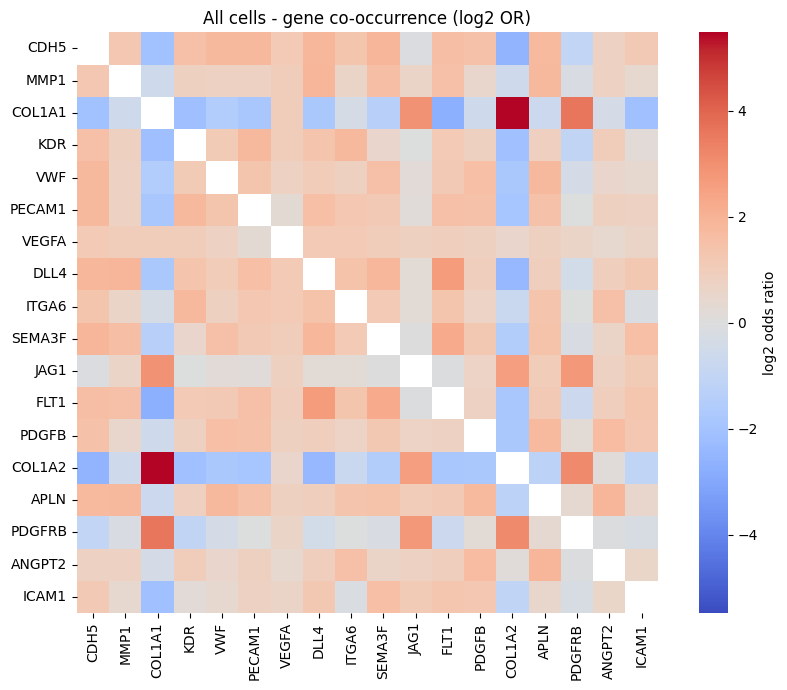

Significant pairs (FDR<0.05): 123  (co-occurring: 101, exclusive: 22)

Strongest co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,608,509,278,23.719782,44.439079,5.473757,2.855165e-252
45,COL1A1,PDGFRB,608,216,75,10.065762,12.300088,3.620597,5.718235e-45
144,COL1A2,PDGFRB,509,216,53,8.426765,8.870702,3.149048,2.447154e-27
40,COL1A1,JAG1,608,500,117,23.300376,7.515714,2.909910,3.222867e-50
129,JAG1,PDGFRB,500,216,43,8.277765,6.781509,2.761606,7.033964e-19
101,DLL4,FLT1,1393,721,278,76.979612,6.311400,2.657960,1.171710e-91
127,JAG1,COL1A2,500,509,86,19.506400,5.974506,2.578819,5.394472e-32
118,SEMA3F,FLT1,922,721,171,50.951330,4.798633,2.262624,6.504109e-48
8,CDH5,SEMA3F,4889,922,619,345.493830,3.754721,1.908706,1.601486e-78
148,APLN,ANGPT2,258,525,33,10.381697,3.709444,1.891203,7.441218e-09


Strongest mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
41,COL1A1,FLT1,608,721,5,33.599142,0.149117,-2.745486,1.042010e-09
12,CDH5,COL1A2,4889,509,48,190.733579,0.167086,-2.581338,1.342468e-47
103,DLL4,COL1A2,1393,509,11,54.344830,0.186164,-2.425355,3.267477e-13
33,COL1A1,KDR,608,3548,48,165.339465,0.220978,-2.178025,1.859079e-33
57,KDR,COL1A2,3548,509,41,138.417414,0.228087,-2.132343,1.460748e-27
47,COL1A1,ICAM1,608,388,4,18.081091,0.233402,-2.099109,1.752085e-04
1,CDH5,COL1A1,4889,608,78,227.831072,0.234608,-2.091676,1.026105e-42
82,PECAM1,COL1A2,1960,509,23,76.465088,0.264308,-1.919707,5.414428e-14
133,FLT1,COL1A2,721,509,8,28.128229,0.280914,-1.831799,1.165429e-05
35,COL1A1,PECAM1,608,1960,30,91.337472,0.287018,-1.800788,4.920342e-15


In [25]:
#  Full population (all cells, incl. all-0 and unknown lineage)
res_all, M_all = pairwise_cooccurrence(
    df, GENES, title="All cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

# Readable labels for the summary tables.
show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nStrongest co-occurring gene pairs:")
display(sig.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
print("Strongest mutually-exclusive gene pairs:")
display(sig.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))

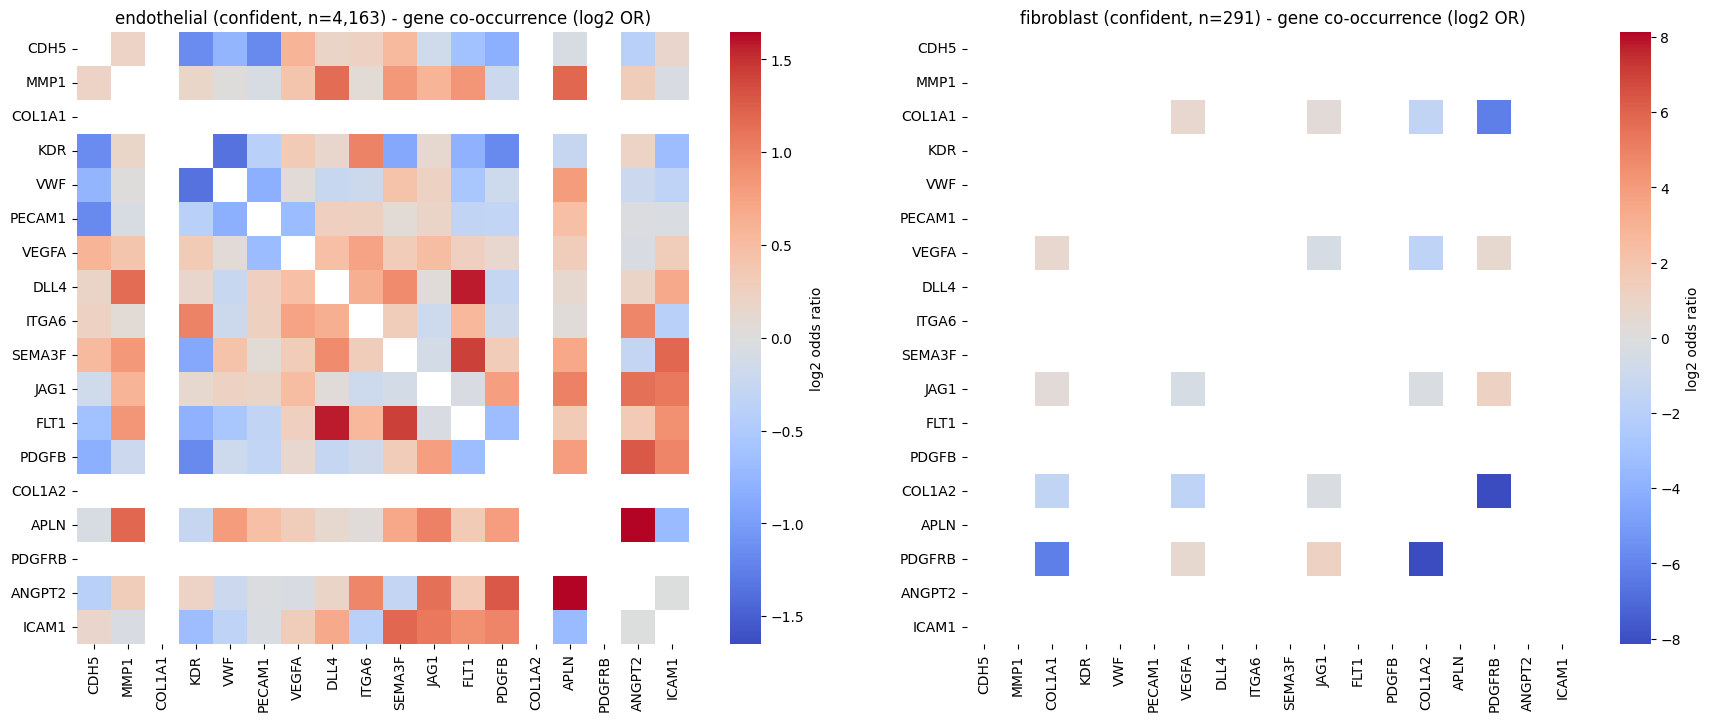

In [26]:
# Within-lineage co-occurrence WITHOUT circularity - use CONFIDENT cells only.
# A confident cell expresses >=2 of its lineage's markers and NONE of the other's, so
# the opposite lineage's markers are all-zero here and their pairs are simply not
# testable. No leave-two-out needed: any testable pair is a genuine co-occurrence.
lineages = ["endothelial", "fibroblast"]
fig, axes = plt.subplots(1, len(lineages), figsize=(9 * len(lineages), 7))
lineage_res = {}
for ax, lineage in zip(axes, lineages):
    sub = df[(df["cell_type"] == lineage) & (df["confident"])]
    res, M = pairwise_cooccurrence(
        sub, GENES, ax=ax,
        title=f"{lineage} (confident, n={len(sub):,}) - gene co-occurrence (log2 OR)")
    lineage_res[lineage] = res
plt.tight_layout(); plt.show()

In [28]:
# Significant within-lineage pairs (confident cells only).
# CAVEAT: a "confident" cell is selected on >=2 of its own markers, which makes those
# defining markers artificially anti-correlate within the subset (collider / Berkson
# bias). So pairs where BOTH genes are that lineage's markers are NOT interpretable -
# we flag them and report the trustworthy (non-marker) pairs separately.
lineage_markers = {"endothelial": set(endo_genes), "fibroblast": set(fibro_genes)}

for lineage in ["endothelial", "fibroblast"]:
    res = lineage_res[lineage].copy()
    mk = lineage_markers[lineage]
    res["both_defining"] = res.gene1.isin(mk) & res.gene2.isin(mk)
    testable = res[res.testable]
    trust = testable[~testable.both_defining]          # interpretable pairs
    biased = testable[testable.both_defining]          # collider-biased, do not interpret
    sig = trust[trust.FDR < 0.05]
    print(f"{lineage}: {len(testable)} testable pairs "
          f"({len(trust)} interpretable, {len(biased)} defining-marker pairs excluded); "
          f"{len(sig)} interpretable & significant (FDR<0.05)  "
          f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("  strongest co-occurring (non-marker pairs):")
    display(trust.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
    print("  strongest mutually-exclusive (non-marker pairs):")
    display(trust.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))
    if len(biased):
        print("  defining-marker pairs (collider-biased, NOT interpreted):")
        display(biased[cols].rename(columns=show_cols))

endothelial: 105 testable pairs (90 interpretable, 15 defining-marker pairs excluded); 28 interpretable & significant (FDR<0.05)  (co-occurring: 25, exclusive: 3)
  strongest co-occurring (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
148,APLN,ANGPT2,160,262,26,10.069661,3.138670,1.650154,4.018940e-05
101,DLL4,FLT1,885,612,243,130.103291,2.984213,1.577350,7.203636e-28
118,SEMA3F,FLT1,550,612,154,80.855153,2.681724,1.423161,7.048073e-17
141,PDGFB,ANGPT2,690,262,81,43.425414,2.425677,1.278388,2.839330e-08
29,MMP1,APLN,599,160,43,23.021859,2.293456,1.197524,1.648422e-04
124,SEMA3F,ICAM1,550,182,45,24.045160,2.275777,1.186359,1.154112e-04
22,MMP1,DLL4,599,885,206,127.339659,2.228471,1.156054,1.264766e-14
130,JAG1,ANGPT2,157,262,19,9.880855,2.176095,1.121741,2.489635e-02
131,JAG1,ICAM1,157,182,13,6.863800,2.115167,1.080771,8.095063e-02
128,JAG1,APLN,157,160,11,6.034110,2.025466,1.018254,1.499088e-01


  strongest mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
53,KDR,SEMA3F,2565,550,266,338.878213,0.535479,-0.901099,1.877358e-10
149,APLN,ICAM1,160,182,4,6.994956,0.616238,-0.698442,6.490350e-01
75,PECAM1,VEGFA,1655,1704,564,677.424934,0.620568,-0.688338,4.236346e-12
61,KDR,ICAM1,2565,182,92,112.137881,0.623342,-0.681904,9.983903e-03
15,CDH5,ANGPT2,3306,262,196,208.064377,0.751903,-0.411382,1.657987e-01
116,ITGA6,ICAM1,162,182,5,7.082393,0.752417,-0.410396,1.000000e+00
74,VWF,ICAM1,1811,182,69,79.174153,0.786986,-0.345589,3.281828e-01
123,SEMA3F,ANGPT2,550,262,29,34.614461,0.818958,-0.288138,6.864149e-01
102,DLL4,PDGFB,885,690,129,146.685083,0.828477,-0.271466,1.968628e-01
58,KDR,APLN,2565,160,92,98.582753,0.835550,-0.259201,5.909403e-01


  defining-marker pairs (collider-biased, NOT interpreted):


...

,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
129,JAG1,PDGFRB,69,78,27,18.494845,2.154769,1.107533,0.469918
36,COL1A1,VEGFA,280,113,110,108.728522,1.573942,0.654383,1.000000
95,VEGFA,PDGFRB,113,78,36,30.288660,1.512638,0.597066,1.000000
40,COL1A1,JAG1,280,69,67,66.391753,1.201405,0.264723,1.000000
127,JAG1,COL1A2,69,260,61,61.649485,0.852278,-0.230604,1.000000
90,VEGFA,JAG1,113,69,23,26.793814,0.739916,-0.434567,1.000000
93,VEGFA,COL1A2,113,260,93,100.962199,0.313142,-1.675113,0.151948


  strongest mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
93,VEGFA,COL1A2,113,260,93,100.962199,0.313142,-1.675113,0.151948
90,VEGFA,JAG1,113,69,23,26.793814,0.739916,-0.434567,1.000000
127,JAG1,COL1A2,69,260,61,61.649485,0.852278,-0.230604,1.000000
40,COL1A1,JAG1,280,69,67,66.391753,1.201405,0.264723,1.000000
95,VEGFA,PDGFRB,113,78,36,30.288660,1.512638,0.597066,1.000000
36,COL1A1,VEGFA,280,113,110,108.728522,1.573942,0.654383,1.000000
129,JAG1,PDGFRB,69,78,27,18.494845,2.154769,1.107533,0.469918


  defining-marker pairs (collider-biased, NOT interpreted):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,280,260,249,250.171821,0.344375,-1.537946,1.000000e+00
45,COL1A1,PDGFRB,280,78,67,75.051546,0.013746,-6.184839,2.269806e-05
144,COL1A2,PDGFRB,260,78,47,69.690722,0.003531,-8.145517,1.461939e-18


## 2. Which gene states define distinct cell states?

**Biological question:** we've converted the on/off genes into a single 18-gene state. Can we group those into families of cell state? Are these groups robust if we use different approaches to identify them.
We split into cell type, otherwise the main identified differences will be endothelial vs fibroblast

Several ways to try and group the cell state:

| Approach | Type | What "similar" means biologically |
|---|---|---|
| Hierarchical (Jaccard) | unsupervised | states are similar when they switch **on the same genes** (jointly-off genes ignored) |
| Hierarchical (Hamming) | unsupervised | states are similar when they **agree on on *and* off** genes (off genes count) |
| KMeans (at matched K) | unsupervised | Euclidean clustering of the 0/1 gene vectors - groups cells by their **overall on/off profile** (close to Hamming) |
| UMAP | visualisation | 2-D embedding of the Jaccard neighbour graph (shared **on** genes) |
| Bernoulli mixture | probabilistic | generative on/off model; genes independent given state, K chosen by BIC |
| Consensus | ensemble | fuses the three clusterings by co-association; keeps cells together only when the methods agree, and scores a **per-cell confidence** |

To compare the methods fairly, the Bernoulli mixture picks the number of states **K** (by BIC) and that same K is **forced on KMeans and hierarchical**, so a low agreement means genuine disagreement rather than a granularity mismatch. Crucially, **hierarchical now clusters the cells directly** (each cell one observation, abundance-weighted) instead of clustering the *unique* gene states with every state weighted equally - the latter placed its boundaries differently from the (cell-weighted) KMeans and Bernoulli methods and depressed the ARI for a reason that was an artefact of representation rather than biology. The run cell prints the old state-level score next to the new cell-level one so this effect is explicit. (Leiden on the Jaccard graph is kept in the code as an optional view, but it leaves rare states stranded in a merged "other" cluster and so lines up poorly; KMeans is used as the third method instead.)

Finally the three methods are fused into a **consensus** partition via a co-association matrix (two cells stay together only when the methods agree). This gives one robust headline labelling plus a **per-cell confidence** - the fraction of methods that consistently co-group each cell - which directly quantifies how much of each lineage is genuinely structured versus an ambiguous continuum.

**Jaccard vs Hamming** is the key choice. Jaccard measures overlap of the genes
that are *on* genes only, so two cells are similar only when they co-express the
same markers, but shared "off" genes don't count towards "similarity". Hamming counts every gene
that differs, so two mostly-silent cells look similar just for sharing their *off* genes.
Jaccard therefore asks "which genes are co-activated?", Hamming asks "how identical are the
full profiles, off genes included included?".

- "jaccard": distance uses only the genes that are ON in at least one of the two
    states (shared-on / union-on). States are similar when they switch on the *same*
    genes; jointly-off genes are ignored. Best when co-expression of specific markers
    defines a programme and the many silent genes should not drive similarity
- "hamming": fraction of *all* genes that differ, so agreement on OFF genes also
    counts as similarity. Mostly-silent states then cluster together simply for being
    silent.

**Agreement across methods:** a high Adjusted Rand Index between an **unsupervised** method
(KMeans / hierarchical) and the **probabilistic** Bernoulli mixture tells us the structure
is real biology rather than an artefact of one clustering choice. We also report the
**Adjusted Mutual Information** (AMI), which is less sensitive to differing cluster sizes.



In [93]:
# Shared helpers + a readable cluster summariser used by every approach in section 2.
from scipy.spatial.distance import squareform   # co-association -> condensed distance

def build_state_matrix(cells, genes):
    """Collapse cells down to their unique gene states.

    Returns:
        state_matrix    - one row per distinct on/off pattern, one column per gene
                          (0/1), ordered from most to least common.
        cells_per_state - how many cells carry each state (same row order).
    """
    cells_per_state = cells.groupby("binary_state").size().sort_values(ascending=False)
    state_matrix = pd.DataFrame(
        [[int(bit) for bit in state] for state in cells_per_state.index],
        index=cells_per_state.index, columns=genes,
    )
    return state_matrix, cells_per_state


def binary_state_to_code(binary_state):
    """'100100...' -> '1_4' (1-indexed positions of the ON genes; '0' if none on)."""
    genes_on = [str(position + 1) for position, bit in enumerate(binary_state) if bit == "1"]
    return "_".join(genes_on) if genes_on else "0"


def state_code_to_gene_names(state_code, genes):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the 1-indexed gene order ('0' -> 'none')."""
    if state_code == "0":
        return "none"
    return ", ".join(genes[int(position) - 1] for position in state_code.split("_"))


def describe_clusters(cells, cell_labels, genes, method_name, cell_type, top_states=3):
    """Print a plain-English summary of one method's clusters for one cell type.

    For every cluster it lists the gene states that dominate it, e.g.
    "cluster 1 (120 cells, 34%): likely states include 60% 1_4 (CDH5, KDR); ...".
    Cells with label -1 (unassigned) are ignored. Returns the same information as a
    tidy DataFrame so it can be collected and saved.
    """
    labels = pd.Series(cell_labels, index=cells.index)
    assigned = labels[labels >= 0]
    cluster_sizes = assigned.value_counts()
    n_cells = len(assigned)
    print(f"{len(cluster_sizes)} clusters identified for {cell_type} cells "
          f"({method_name}, {n_cells:,} cells):")

    summary_rows = []
    for cluster_id in cluster_sizes.index:
        member_index = assigned[assigned == cluster_id].index
        n = len(member_index)
        state_counts = cells.loc[member_index, "binary_state"].value_counts()
        described = [
            f"{100 * count / n:.0f}% {binary_state_to_code(state)} "
            f"({state_code_to_gene_names(binary_state_to_code(state), genes)})"
            for state, count in state_counts.head(top_states).items()
        ]
        main_states = "; ".join(described)
        print(f"  cluster {cluster_id} ({n:,} cells, {100 * n / n_cells:.0f}%): "
              f"likely states include {main_states}")
        summary_rows.append({
            "cell_type": cell_type,
            "method": method_name,
            "cluster": cluster_id,
            "n_cells": n,
            "pct_of_cell_type": 100 * n / n_cells,
            "main_states": main_states,
        })
    print()
    return pd.DataFrame(summary_rows)


# ---- Approach 1: hierarchical clustering (now clusters CELLS, not unique states) ----

def hierarchical_cell_labels(cells, genes, metric="jaccard", max_clusters=8,
                             by="cell", max_cells_for_full=8000):
    """Group cells into recurring on/off programmes ("cell states") within a lineage.

    `by` controls the representation - this is the key fairness fix of Section 2:
        "cell"  - cluster every CELL as its own observation. A gene state carried by
                  500 cells therefore pulls 500x harder than one seen in 3 cells,
                  exactly like KMeans and the Bernoulli mixture. This is what we compare.
        "state" - cluster the UNIQUE states and broadcast the label back to their cells
                  (the old behaviour). Every state counts equally regardless of how many
                  cells carry it, so the cut lands in a different place and the ARI
                  against the (abundance-weighted) other two methods is depressed for a
                  reason that is an artefact of representation, not biology. Kept only so
                  we can show the before/after.

    `metric` decides what "similar" means:
        "jaccard" - similar when states share the same ON genes (OFF genes ignored).
        "hamming" - similar when states agree on ON and OFF genes (silent genes count).
    Average linkage; the tree is cut to at most `max_clusters` groups.

    Returns:
        cell_labels - one cluster id per cell (all -1 if too few distinct states).
        plot_bundle - (state_matrix, linkage_tree, state_cluster_ids) for the clustermap,
                      a state-level VIEW of the result (each state coloured by the cluster
                      most of its cells fall in), or None when clustering was skipped.
    """
    gene_matrix = cells[genes].astype(int).to_numpy()
    n_unique = len(np.unique(gene_matrix, axis=0))
    if n_unique < 3:
        return np.full(len(cells), -1), None
    n_clusters = min(max_clusters, n_unique)

    # State-level tree is always built - it orders the rows of the clustermap.
    state_matrix, _ = build_state_matrix(cells, genes)
    linkage_states = linkage(pdist(state_matrix.values, metric=metric), method="average")

    if by == "state" or len(cells) > max_cells_for_full:
        # Old view (or memory guard for very large lineages): cut the state tree and
        # hand each cell its state's cluster.
        state_ids = fcluster(linkage_states, t=n_clusters, criterion="maxclust")
        cell_labels = cells["binary_state"].map(
            pd.Series(state_ids, index=state_matrix.index)).to_numpy()
        state_cluster_ids = state_ids
    else:
        # Fair view: cluster the full cell x gene matrix so common states dominate.
        linkage_cells = linkage(pdist(gene_matrix, metric=metric), method="average")
        cell_labels = fcluster(linkage_cells, t=n_clusters, criterion="maxclust")
        # For the clustermap, colour each state by its cells' majority cluster.
        state_cluster_ids = (
            pd.Series(cell_labels, index=cells.index)
            .groupby(cells["binary_state"]).agg(lambda s: s.mode().iloc[0])
            .reindex(state_matrix.index).to_numpy())

    return cell_labels, (state_matrix, linkage_states, state_cluster_ids)


def plot_state_clustermap(state_matrix, linkage_tree, cluster_ids, cell_type, n_cells):
    """Clustermap of the gene states for one cell type, rows coloured by cluster."""
    cluster_colors = [sns.color_palette("tab20", cluster_ids.max())[c - 1] for c in cluster_ids]
    grid = sns.clustermap(
        state_matrix, row_linkage=linkage_tree, col_cluster=False, cmap="Greys",
        row_colors=cluster_colors, yticklabels=False, cbar_pos=None,
        figsize=(9, min(14, 0.18 * len(state_matrix) + 3)))
    grid.ax_heatmap.set_xlabel("Gene")
    grid.figure.suptitle(
        f"{cell_type}: {len(state_matrix)} gene states ({n_cells:,} cells) "
        f"-> {cluster_ids.max()} clusters", y=1.02)
    plt.show()


# ---- Consensus clustering: fuse several methods into one robust partition ----

def consensus_labels(method_label_dict, n_clusters, max_cells=8000):
    """Fuse per-cell labels from several methods via a co-association matrix.

    For every pair of cells we count in how many of the input methods they land in the
    same cluster; dividing by the number of methods gives a co-association in [0, 1]
    (1.0 = every method groups them together). Average-linkage clustering of
    (1 - co-association) keeps two cells together only when the methods agree, so the
    result is robust to any single algorithm's quirks.

    Also returns a PER-CELL confidence: the mean co-association between a cell and the
    other members of its own consensus cluster. High confidence = the methods
    consistently co-group that cell; low confidence flags cells sitting in the ambiguous
    continuum between states. This lets us quantify how much of a lineage is genuinely
    structured versus method-dependent.

    Returns (labels, confidence), or (None, None) if there are too many cells to build
    the dense n x n matrix.
    """
    label_arrays = [np.asarray(lab) for lab in method_label_dict.values()]
    n = len(label_arrays[0])
    if n > max_cells:
        return None, None
    co_association = np.zeros((n, n), dtype=np.float64)
    for lab in label_arrays:
        co_association += (lab[:, None] == lab[None, :])
    co_association /= len(label_arrays)

    tree = linkage(squareform(1.0 - co_association, checks=False), method="average")
    labels = fcluster(tree, t=n_clusters, criterion="maxclust")

    confidence = np.full(n, np.nan)
    for cluster_id in np.unique(labels):
        members = np.where(labels == cluster_id)[0]
        if len(members) > 1:
            block = co_association[np.ix_(members, members)]
            # exclude the cell's self-association (always 1.0) from its own mean
            confidence[members] = (block.sum(axis=1) - 1.0) / (len(members) - 1)
    return labels, confidence



In [90]:
#  Approach 2: Bernoulli mixture (probabilistic) 

def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for _ in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, and the
    BIC score (lower = better fit once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for _ in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states



In [91]:
# Approach 3: KMeans (at matched K) + UMAP on the gene vectors
# (Leiden is kept below as an optional graph-based view but is no longer the third
# method in the run-all cell - KMeans lines up far better with the other two.)

def merge_small_clusters(labels, max_clusters):
    """Keep the largest clusters, fold the rest into one 'other' group.

    Guarantees at most `max_clusters` labels and renumbers them 0..n-1 by size
    (the merged 'other' group, if any, is the last id). Needed because rare gene
    states form disconnected islands in the graph that resolution tuning can't merge.
    """
    sizes = pd.Series(labels).value_counts()
    if len(sizes) <= max_clusters:
        remap = {old: new for new, old in enumerate(sizes.index)}
        return np.array([remap[label] for label in labels])
    kept = list(sizes.index[:max_clusters - 1])
    remap = {old: new for new, old in enumerate(kept)}
    other_id = max_clusters - 1
    return np.array([remap.get(label, other_id) for label in labels])


def kmeans_cluster_gene_space(gene_matrix, n_clusters, seed=0):
    """Cluster cells directly on their 0/1 gene vectors with KMeans at exactly K.

    Euclidean KMeans on binary vectors groups cells by their overall on/off profile
    (close to Hamming), giving a third view forced to the same K so it is directly
    comparable with the Bernoulli mixture and hierarchical clustering. Unlike the
    graph/Leiden view it never leaves rare states stranded in an 'other' bucket.
    """
    n_clusters = min(n_clusters, len(np.unique(gene_matrix, axis=0)))
    return KMeans(n_clusters=n_clusters, n_init=10, random_state=seed).fit_predict(gene_matrix)


def leiden_cluster_gene_space(gene_matrix, k_neighbors=15, seed=0, max_clusters=8, n_clusters=None):
    """Cluster cells by shared ON genes.

    Builds a k-nearest-neighbour graph with the Jaccard metric (cells are neighbours
    when they switch on the same genes; shared OFF genes are ignored) and finds
    communities in it with Leiden.

    If `n_clusters` is given the resolution is *raised* until at least that many
    communities appear, then they are merged down to exactly `n_clusters` (used to
    match the K chosen by the Bernoulli mixture so the methods are comparable).
    Otherwise the resolution is *lowered* until at most `max_clusters` communities
    remain. Either way leftover rare-state islands are folded into a single 'other'
    cluster. Returns one label per cell.
    """
    neighbors = NearestNeighbors(n_neighbors=k_neighbors, metric="jaccard").fit(gene_matrix)
    _, neighbor_index = neighbors.kneighbors(gene_matrix)
    edges = {(min(cell, int(other)), max(cell, int(other)))
             for cell in range(neighbor_index.shape[0]) for other in neighbor_index[cell, 1:]}
    graph = ig.Graph(n=len(gene_matrix), edges=list(edges))

    def partition_at(resolution):
        return np.array(leidenalg.find_partition(
            graph, leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=resolution, seed=seed).membership)

    if n_clusters is not None:
        labels = None
        for resolution in [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
            labels = partition_at(resolution)
            if len(set(labels)) >= n_clusters:
                break
        return merge_small_clusters(labels, n_clusters)

    labels = None
    for resolution in [1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.01]:
        labels = partition_at(resolution)
        if len(set(labels)) <= max_clusters:
            break
    return merge_small_clusters(labels, max_clusters)


def umap_embed_gene_space(gene_matrix, k_neighbors=15, seed=0):
    """2-D UMAP of the same Jaccard neighbour structure - for visualisation only."""
    return umap.UMAP(metric="jaccard", n_neighbors=k_neighbors, min_dist=0.1,
                     random_state=seed).fit_transform(gene_matrix)

CELL TYPE: endothelial  (5,180 cells)
Bernoulli BIC picked K = 6; forcing K on KMeans and hierarchical.

6 clusters identified for endothelial cells (Bernoulli mixture, 5,180 cells):
  cluster 4 (2,129 cells, 41%): likely states include 12% 1_4 (CDH5, KDR); 9% 1_4_7 (CDH5, KDR, VEGFA); 7% 1 (CDH5)
  cluster 2 (1,014 cells, 20%): likely states include 45% 4 (KDR); 18% 4_7 (KDR, VEGFA); 7% 4_5 (KDR, VWF)
  cluster 0 (680 cells, 13%): likely states include 33% 5 (VWF); 26% 1_5 (CDH5, VWF); 16% 1_5_7 (CDH5, VWF, VEGFA)
  cluster 5 (605 cells, 12%): likely states include 20% 1_6 (CDH5, PECAM1); 19% 6 (PECAM1); 15% 4_6 (KDR, PECAM1)
  cluster 1 (473 cells, 9%): likely states include 12% 13 (PDGFB); 8% 1_13 (CDH5, PDGFB); 6% 1_7_13 (CDH5, VEGFA, PDGFB)
  cluster 3 (279 cells, 5%): likely states include 11% 12 (FLT1); 7% 1_12 (CDH5, FLT1); 5% 1_4_12 (CDH5, KDR, FLT1)



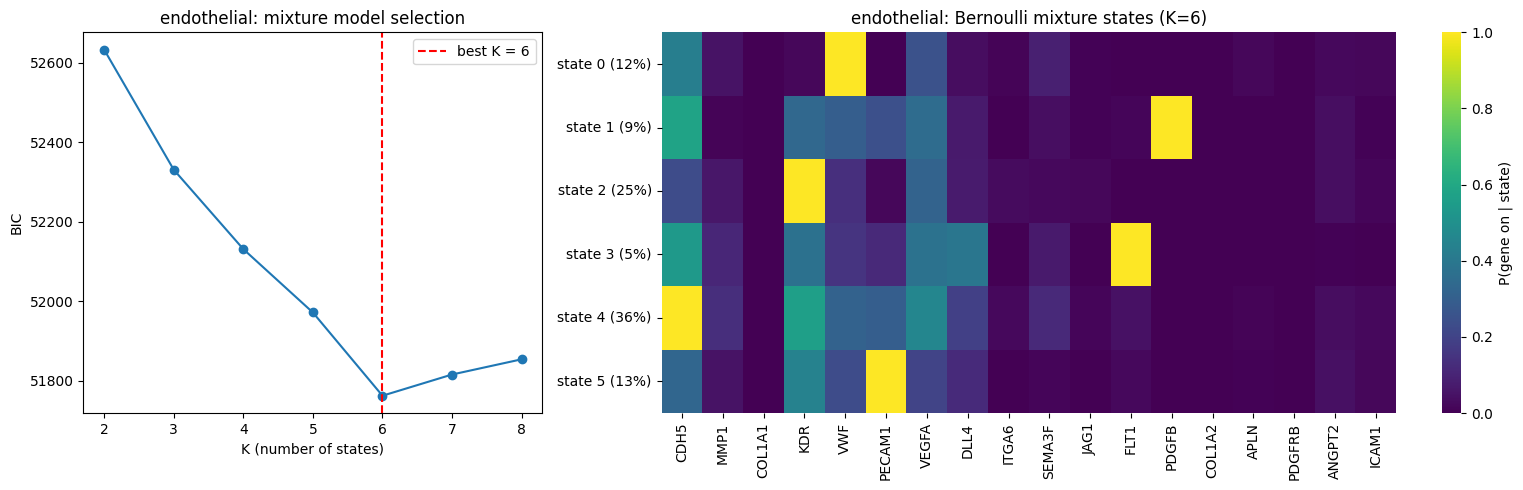

6 clusters identified for endothelial cells (KMeans, 5,180 cells):
  cluster 1 (1,355 cells, 26%): likely states include 34% 4 (KDR); 13% 4_7 (KDR, VEGFA); 7% 4_6 (KDR, PECAM1)
  cluster 0 (1,156 cells, 22%): likely states include 22% 1_4 (CDH5, KDR); 12% 1 (CDH5); 8% 1_4_6 (CDH5, KDR, PECAM1)
  cluster 3 (857 cells, 17%): likely states include 26% 5 (VWF); 21% 1_5 (CDH5, VWF); 13% 1_5_7 (CDH5, VWF, VEGFA)
  cluster 5 (703 cells, 14%): likely states include 27% 1_4_7 (CDH5, KDR, VEGFA); 10% 1_4_5_7 (CDH5, KDR, VWF, VEGFA); 8% 1_4_6_7 (CDH5, KDR, PECAM1, VEGFA)
  cluster 4 (684 cells, 13%): likely states include 17% 1_6 (CDH5, PECAM1); 17% 6 (PECAM1); 6% 1_6_7 (CDH5, PECAM1, VEGFA)
  cluster 2 (425 cells, 8%): likely states include 23% 1_7 (CDH5, VEGFA); 13% 13 (PDGFB); 9% 1_13 (CDH5, PDGFB)

Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): jaccard = 0.201, hamming = 0.183 -> using jaccard
Representation fix (jaccard): mean ARI vs Bernoulli & KMeans  state-level (old) = 0

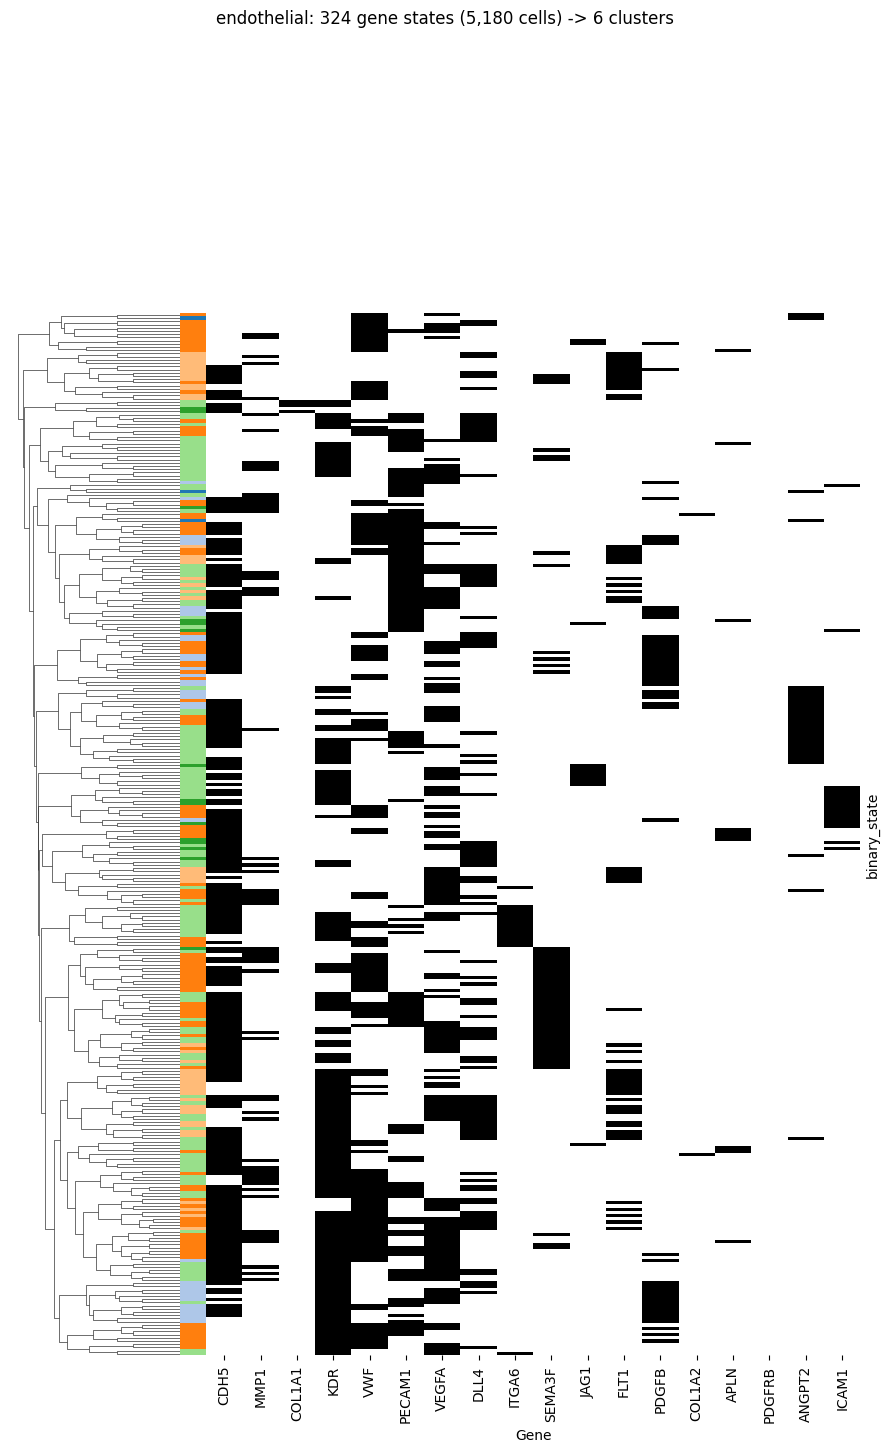

c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


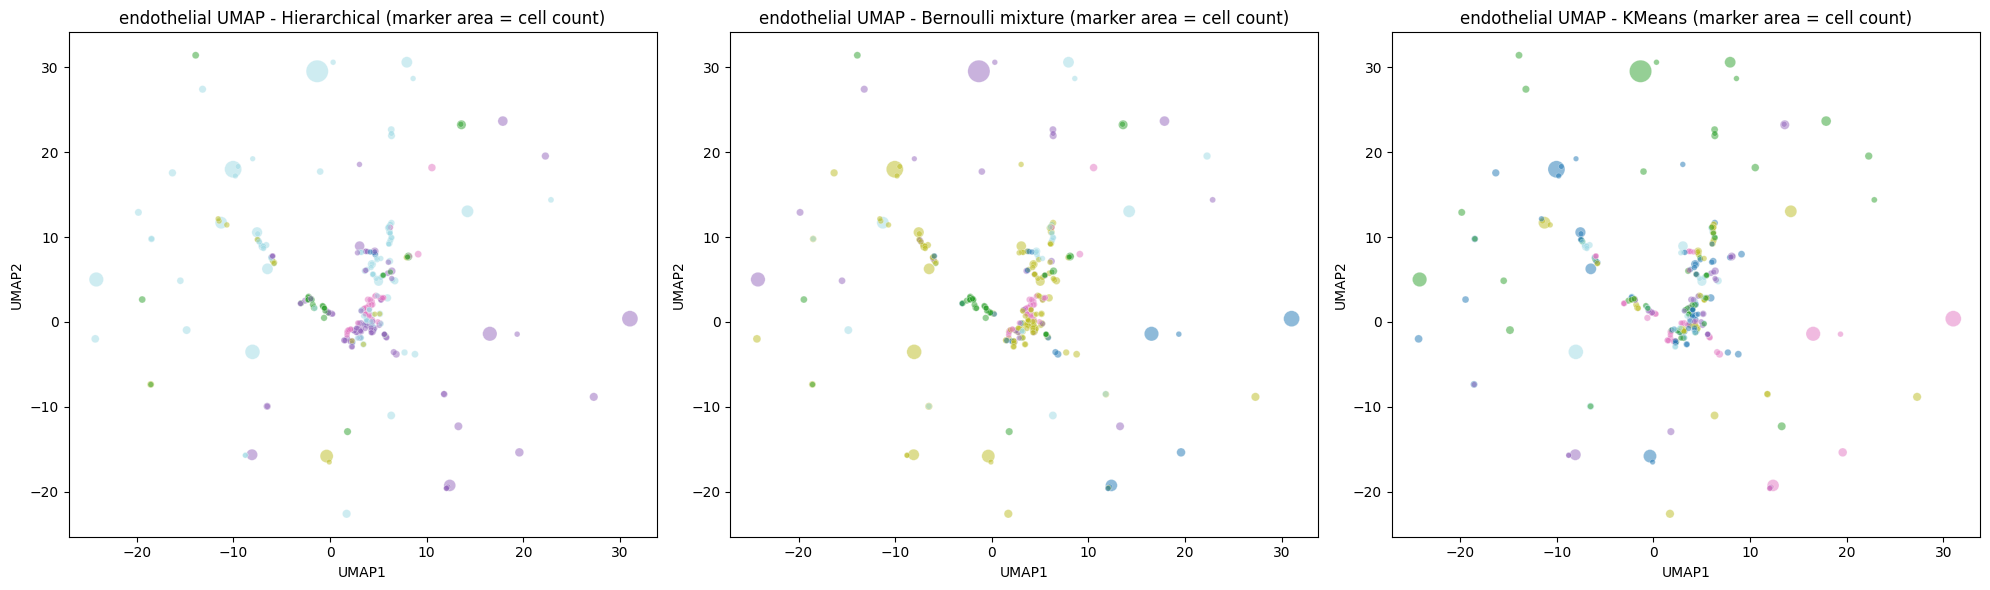

Agreement for endothelial at K=6 (1 = identical, ~0 = chance):
        kmeans vs bernoulli   : ARI = 0.416   AMI = 0.516
        kmeans vs hierarchical: ARI = 0.175   AMI = 0.232
     bernoulli vs hierarchical: ARI = 0.227   AMI = 0.433

Consensus (co-association of the 3 methods, K=6):
  hierarchical vs consensus  : ARI = 0.425
     bernoulli vs consensus  : ARI = 0.712
        kmeans vs consensus  : ARI = 0.474
  mean per-cell confidence: 0.727; cells with >=0.8 confidence: 36.3%

6 clusters identified for endothelial cells (Consensus, 5,180 cells):
  cluster 4 (1,574 cells, 30%): likely states include 17% 1_4 (CDH5, KDR); 12% 1_4_7 (CDH5, KDR, VEGFA); 9% 1 (CDH5)
  cluster 3 (1,235 cells, 24%): likely states include 18% 5 (VWF); 14% 1_5 (CDH5, VWF); 9% 1_5_7 (CDH5, VWF, VEGFA)
  cluster 6 (1,092 cells, 21%): likely states include 42% 4 (KDR); 16% 4_7 (KDR, VEGFA); 6% 4_5 (KDR, VWF)
  cluster 5 (562 cells, 11%): likely states include 21% 1_6 (CDH5, PECAM1); 21% 6 (PECAM1); 17% 4_6 (K

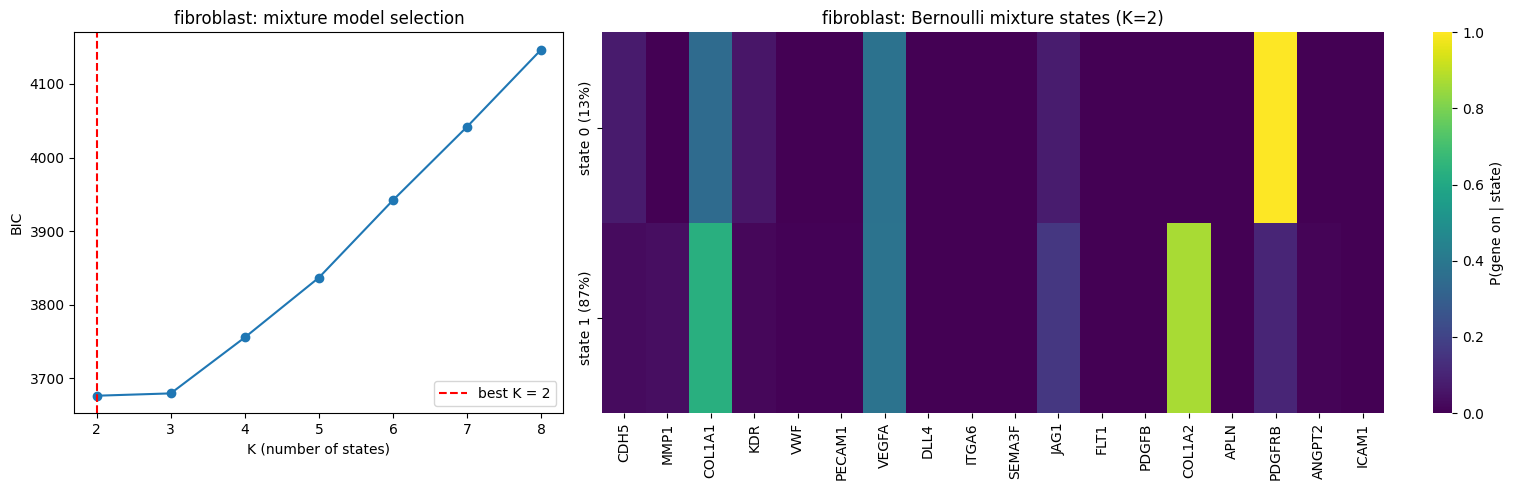

2 clusters identified for fibroblast cells (KMeans, 535 cells):
  cluster 1 (318 cells, 59%): likely states include 32% 3_14 (COL1A1, COL1A2); 17% 3_7_14 (COL1A1, VEGFA, COL1A2); 8% 3_11_14 (COL1A1, JAG1, COL1A2)
  cluster 0 (217 cells, 41%): likely states include 35% 14 (COL1A2); 22% 7_14 (VEGFA, COL1A2); 12% 16 (PDGFRB)

Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): jaccard = 0.399, hamming = -0.001 -> using jaccard
Representation fix (jaccard): mean ARI vs Bernoulli & KMeans  state-level (old) = 0.378  ->  cell-level (fair) = 0.399

2 clusters identified for fibroblast cells (Hierarchical (jaccard), 535 cells):
  cluster 2 (489 cells, 91%): likely states include 21% 3_14 (COL1A1, COL1A2); 16% 14 (COL1A2); 11% 3_7_14 (COL1A1, VEGFA, COL1A2)
  cluster 1 (46 cells, 9%): likely states include 57% 16 (PDGFRB); 24% 7_16 (VEGFA, PDGFRB); 11% 1_16 (CDH5, PDGFRB)



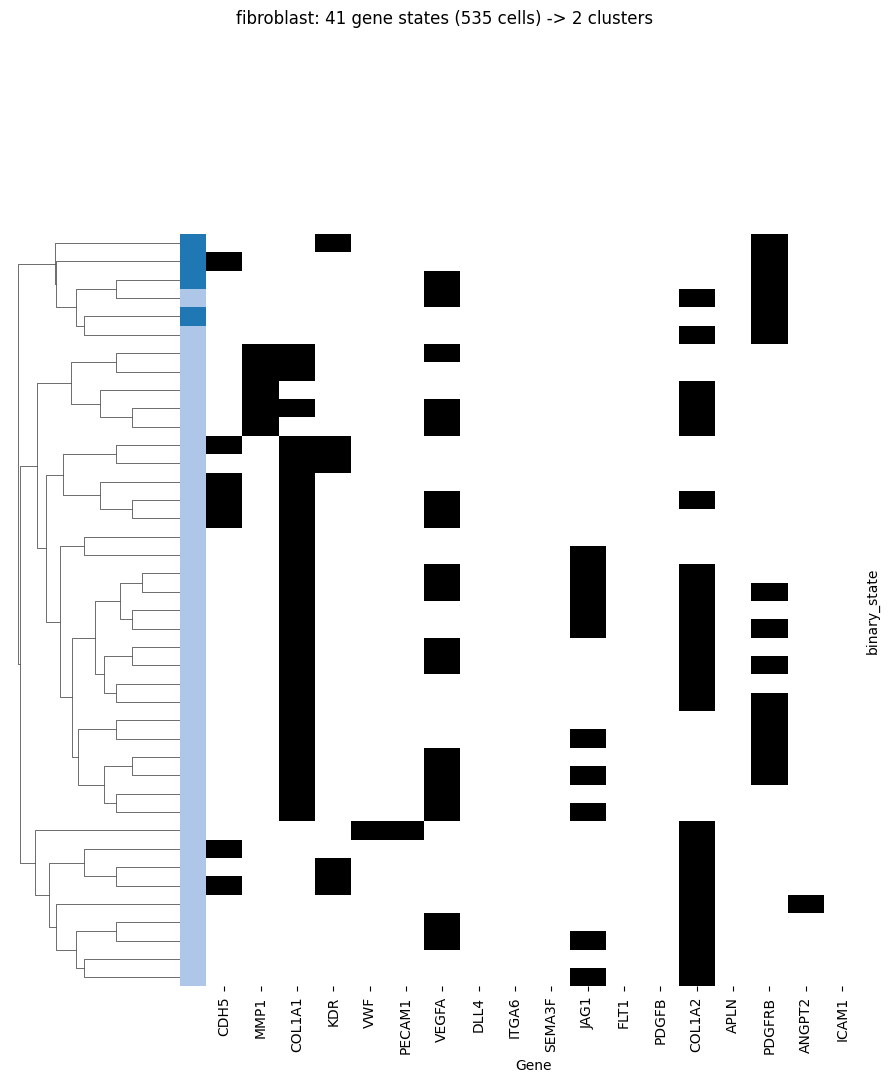

c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


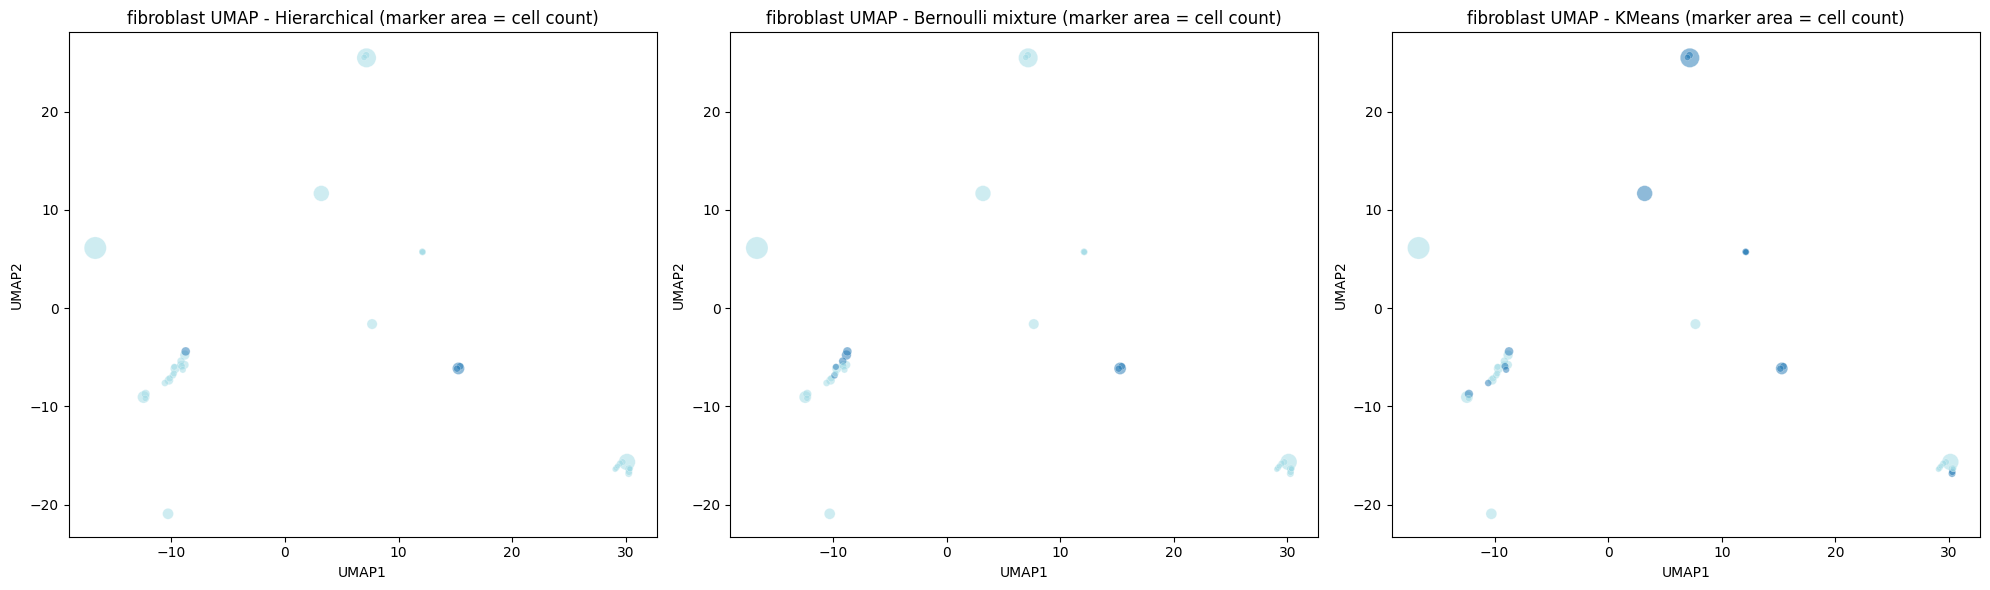

Agreement for fibroblast at K=2 (1 = identical, ~0 = chance):
        kmeans vs bernoulli   : ARI = 0.047   AMI = 0.027
        kmeans vs hierarchical: ARI = 0.108   AMI = 0.171
     bernoulli vs hierarchical: ARI = 0.690   AMI = 0.578

Consensus (co-association of the 3 methods, K=2):
  hierarchical vs consensus  : ARI = 1.000
     bernoulli vs consensus  : ARI = 0.690
        kmeans vs consensus  : ARI = 0.108
  mean per-cell confidence: 0.828; cells with >=0.8 confidence: 62.8%

2 clusters identified for fibroblast cells (Consensus, 535 cells):
  cluster 2 (489 cells, 91%): likely states include 21% 3_14 (COL1A1, COL1A2); 16% 14 (COL1A2); 11% 3_7_14 (COL1A1, VEGFA, COL1A2)
  cluster 1 (46 cells, 9%): likely states include 57% 16 (PDGFRB); 24% 7_16 (VEGFA, PDGFRB); 11% 1_16 (CDH5, PDGFRB)

Saved -> section2_cluster_overview.csv


In [94]:
# ============================================================================
# RUN SECTION 2 - all approaches, SPLIT BY CELL TYPE, MATCHED ON GRANULARITY.
#
# To compare the methods fairly we let the Bernoulli mixture pick the number of
# states K (via BIC), then force that same K on the other methods so any low
# agreement reflects real disagreement, not a granularity mismatch:
#   1. Bernoulli mixture   - probabilistic; K chosen by BIC (drives everything).
#   2. KMeans              - Euclidean clustering of the 0/1 gene vectors at K.
#   3. Hierarchical        - now clusters CELLS at K (by="cell"), so it is weighted by
#                            cell abundance just like KMeans/Bernoulli. Both Jaccard and
#                            Hamming are tried and whichever agrees more is kept. We also
#                            print what the OLD state-level version scored, to show the
#                            gain purely from fixing the representation.
#   4. Agreement (ARI/AMI) - at matched K, do the three methods agree?
#   5. Consensus           - fuse the three into one co-association partition and score a
#                            per-cell confidence, giving a single robust labelling and a
#                            measure of how much of each lineage is genuinely structured.
#
# UMAP (Jaccard) is shown alongside for visualisation only.
# MAX_CLUSTERS caps the BIC search so every method stays readable (< 10 clusters).
# ============================================================================
from sklearn.metrics import adjusted_mutual_info_score

CELL_TYPES = ["endothelial", "fibroblast"]
MAX_CLUSTERS = 8

# Columns section 3 reads later; filled per cell type below (ids offset so they stay
# unique across cell types).
for column in ["hier", "bmm", "kmeans", "consensus"]:
    df[column] = -1
df["umap1"] = np.nan
df["umap2"] = np.nan
df["consensus_confidence"] = np.nan

all_summaries = []

for cell_type in CELL_TYPES:
    cells = df[df.cell_type == cell_type]
    if len(cells) < 10:
        print(f"{cell_type}: only {len(cells)} cells - skipping\n")
        continue
    cell_gene_matrix = cells[GENES].astype(int).to_numpy()
    print("=" * 78)
    print(f"CELL TYPE: {cell_type}  ({len(cells):,} cells)")
    print("=" * 78)

    # --- Approach 1: Bernoulli mixture first - BIC picks K, forced on the rest ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        cell_gene_matrix, candidate_states=range(2, MAX_CLUSTERS + 1))
    bmm_labels = best_mixture["labels"]
    K = best_mixture["n_states"]
    print(f"Bernoulli BIC picked K = {K}; forcing K on KMeans and hierarchical.\n")
    all_summaries.append(describe_clusters(cells, bmm_labels, GENES, "Bernoulli mixture", cell_type))

    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
    axes[0].plot(candidate_ks, bic_values, "o-")
    axes[0].axvline(K, color="red", ls="--", label=f"best K = {K}")
    axes[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{cell_type}: mixture model selection")
    axes[0].legend()
    component_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=GENES,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    sns.heatmap(component_probabilities, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
                cbar_kws={"label": "P(gene on | state)"})
    axes[1].set_title(f"{cell_type}: Bernoulli mixture states (K={K})")
    plt.tight_layout(); plt.show()

    # --- Approach 2: KMeans on the gene vectors, forced to the same K ---
    kmeans_labels = kmeans_cluster_gene_space(cell_gene_matrix, n_clusters=K)
    all_summaries.append(describe_clusters(cells, kmeans_labels, GENES, "KMeans", cell_type))

    # --- Approach 3: hierarchical at K, clustering CELLS (abundance-weighted, fair) ---
    # Try both distance metrics and keep whichever agrees more with the other two methods.
    # by="cell" is the fairness fix: it weights states by cell count exactly like KMeans
    # and Bernoulli, instead of the old state-level cut where every state counted equally.
    hier_options = {}
    for metric in ["jaccard", "hamming"]:
        labels_metric, plot_metric = hierarchical_cell_labels(
            cells, GENES, metric=metric, max_clusters=K, by="cell")
        mean_ari = np.mean([
            adjusted_rand_score(labels_metric, bmm_labels),
            adjusted_rand_score(labels_metric, kmeans_labels),
        ])
        hier_options[metric] = (labels_metric, plot_metric, mean_ari)
    hier_metric = max(hier_options, key=lambda m: hier_options[m][2])
    hier_labels, hier_plot, _ = hier_options[hier_metric]
    print(f"Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): "
          f"jaccard = {hier_options['jaccard'][2]:.3f}, hamming = {hier_options['hamming'][2]:.3f} "
          f"-> using {hier_metric}")

    # Before/after: what the OLD state-level hierarchical (every state equal) would have
    # scored, so the improvement from the fair cell-level representation is explicit.
    hier_labels_state, _ = hierarchical_cell_labels(
        cells, GENES, metric=hier_metric, max_clusters=K, by="state")
    old_mean = np.mean([adjusted_rand_score(hier_labels_state, bmm_labels),
                        adjusted_rand_score(hier_labels_state, kmeans_labels)])
    print(f"Representation fix ({hier_metric}): mean ARI vs Bernoulli & KMeans  "
          f"state-level (old) = {old_mean:.3f}  ->  cell-level (fair) = {hier_options[hier_metric][2]:.3f}\n")

    all_summaries.append(describe_clusters(cells, hier_labels, GENES, f"Hierarchical ({hier_metric})", cell_type))
    if hier_plot is not None:
        plot_state_clustermap(*hier_plot, cell_type, len(cells))

    # UMAP: collapse identical gene states to one marker, sized by how many cells share it.
    k_neighbors = min(15, len(cells) - 1)
    embedding = umap_embed_gene_space(cell_gene_matrix, k_neighbors=k_neighbors)
    plot_points = pd.DataFrame({
        "umap1": embedding[:, 0], "umap2": embedding[:, 1],
        "state": cells["binary_state"].to_numpy(),
        "hier": hier_labels, "bmm": bmm_labels, "kmeans": kmeans_labels,
    })
    state_points = (plot_points
        .groupby("state", as_index=False)
        .agg(umap1=("umap1", "first"), umap2=("umap2", "first"),
             hier=("hier", "first"), bmm=("bmm", "first"),
             kmeans=("kmeans", "first"), n_cells=("state", "size"))
        .sort_values("n_cells", ascending=False))
    marker_sizes = 15 + 240 * state_points["n_cells"] / state_points["n_cells"].max()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, column_name, name in zip(axes, ["hier", "bmm", "kmeans"],
                                     ["Hierarchical", "Bernoulli mixture", "KMeans"]):
        ax.scatter(state_points["umap1"], state_points["umap2"], s=marker_sizes,
                   c=state_points[column_name], cmap="tab20", alpha=0.5,
                   edgecolor="white", linewidth=0.3)
        ax.set_title(f"{cell_type} UMAP - {name} (marker area = cell count)")
        ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    plt.tight_layout(); plt.show()

    # --- Approach 4: at matched K, do the methods agree within this cell type? ---
    # ARI is chance-corrected exact-match agreement; AMI is the information-theoretic
    # analogue and is less sensitive to differing cluster sizes - we report both.
    print(f"Agreement for {cell_type} at K={K} (1 = identical, ~0 = chance):")
    method_labels = {"hierarchical": hier_labels, "bernoulli": bmm_labels, "kmeans": kmeans_labels}
    for method_a, method_b in [("kmeans", "bernoulli"), ("kmeans", "hierarchical"), ("bernoulli", "hierarchical")]:
        labels_a, labels_b = method_labels[method_a], method_labels[method_b]
        both_assigned = (labels_a >= 0) & (labels_b >= 0)
        ari = adjusted_rand_score(labels_a[both_assigned], labels_b[both_assigned])
        ami = adjusted_mutual_info_score(labels_a[both_assigned], labels_b[both_assigned])
        print(f"  {method_a:>12} vs {method_b:<12}: ARI = {ari:.3f}   AMI = {ami:.3f}")
    print()

    # --- Approach 5: consensus - fuse the three methods into one robust partition ---
    # Two cells stay together only when the methods agree they belong together; the
    # per-cell confidence says how consistently each cell is co-grouped (low = ambiguous
    # continuum). ARI of each method vs the consensus shows which methods drive it.
    cons_labels, cons_conf = consensus_labels(method_labels, n_clusters=K)
    if cons_labels is not None:
        print(f"Consensus (co-association of the 3 methods, K={K}):")
        for method_name, labels in method_labels.items():
            print(f"  {method_name:>12} vs consensus  : ARI = {adjusted_rand_score(cons_labels, labels):.3f}")
        valid = ~np.isnan(cons_conf)
        print(f"  mean per-cell confidence: {np.nanmean(cons_conf):.3f}; "
              f"cells with >=0.8 confidence: {100 * np.mean(cons_conf[valid] >= 0.8):.1f}%\n")
        all_summaries.append(describe_clusters(cells, cons_labels, GENES, "Consensus", cell_type))
        cons_offset = int(df["consensus"].max()) + 1
        df.loc[cells.index, "consensus"] = cons_labels + cons_offset
        df.loc[cells.index, "consensus_confidence"] = cons_conf

    # Store labels back on df (offset so cell types keep distinct ids for section 3).
    hier_offset = int(df["hier"].max()) + 1
    bmm_offset = int(df["bmm"].max()) + 1
    kmeans_offset = int(df["kmeans"].max()) + 1
    df.loc[cells.index, "hier"] = np.where(hier_labels >= 0, hier_labels + hier_offset, -1)
    df.loc[cells.index, "bmm"] = bmm_labels + bmm_offset
    df.loc[cells.index, "kmeans"] = kmeans_labels + kmeans_offset
    df.loc[cells.index, "umap1"] = embedding[:, 0]
    df.loc[cells.index, "umap2"] = embedding[:, 1]

# One tidy, readable table of every cluster from every method and cell type.
cluster_overview = pd.concat(all_summaries, ignore_index=True)
cluster_overview.to_csv(output_dir / "section2_cluster_overview.csv", index=False)
print("Saved -> section2_cluster_overview.csv")


### Is the structure real? Null / clusterability test

The fair-representation fix didn't lift the endothelial agreement, which leaves two possibilities: a genuine (if weak) continuum with real co-expression structure, or essentially no structure (noise). The cell below settles it with a **null model**: each gene is redrawn *independently* at its observed ON-rate, so the marginals are preserved but every gene-gene relationship is destroyed. If the real methods agree **more than** they do on this null, the agreement comes from real co-expression - not from the marginals alone. The **agreement-vs-K** curves also show where real structure is strongest, which is the most biologically meaningful number of states to read.


endothelial: at BIC K=6  real ARI=0.272  vs null 0.087±0.046  (z=4.0)  |  most-structured K=8 (z=11.8)
fibroblast: at BIC K=2  real ARI=0.282  vs null 0.005±0.008  (z=35.8)  |  most-structured K=2 (z=35.8)


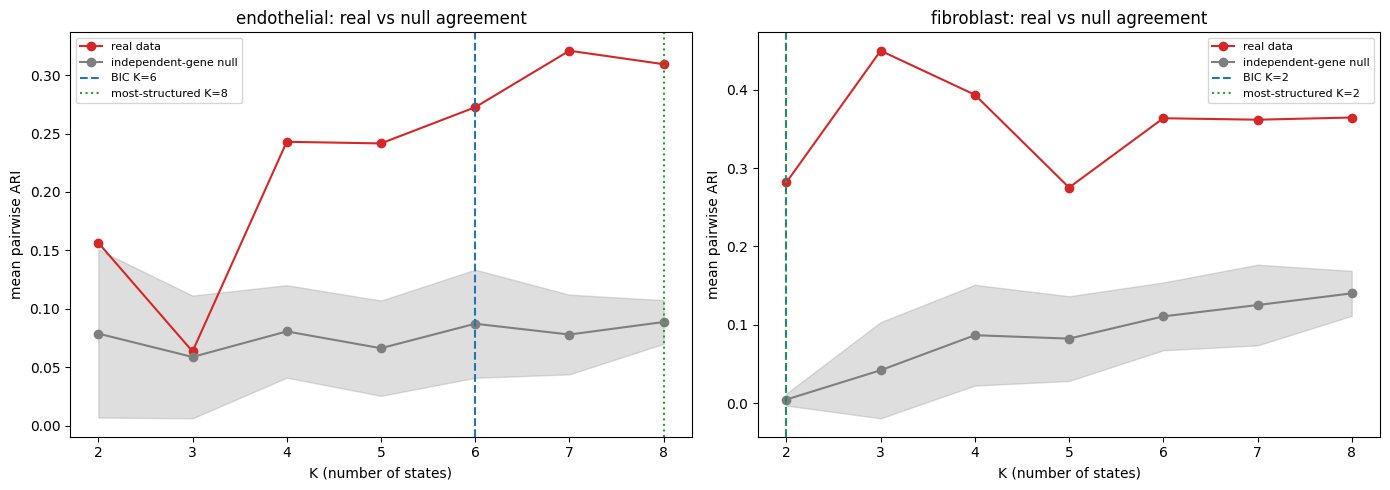

In [95]:
# ============================================================================
# DIAGNOSTIC: is the modest inter-method agreement REAL co-expression structure, or
# just what independent genes at these ON-rates would produce by chance?
#
# NULL MODEL (independent-Bernoulli): for each lineage we keep every gene's observed ON
# frequency but draw each gene INDEPENDENTLY, destroying all gene-gene structure while
# matching the marginals. Re-running the same 3-method pipeline on many such null
# datasets gives the agreement you'd get from marginals alone. Reading:
#   real mean ARI >> null band  -> genuine multi-gene (co-expression) structure.
#   real mean ARI within band   -> the "clusters" are an arbitrary cut of a continuum.
#
# We sweep K as well: BIC can over-split a continuum, so the most robust (and most
# biologically meaningful) granularity is the K where real agreement stands furthest
# ABOVE its null - not necessarily the BIC K.
# ============================================================================

def three_method_labels(binary_matrix, K, seed=0, n_restarts=3):
    """Bernoulli / KMeans / cell-level hierarchical (Jaccard) at fixed K on a 0/1 matrix.
    Any all-zero rows (possible in a null draw; never in real recurrent cells) get one
    random gene switched on so the Jaccard distance stays defined."""
    M = np.asarray(binary_matrix, dtype=int).copy()
    zero_rows = np.where(M.sum(axis=1) == 0)[0]
    if len(zero_rows):
        M[zero_rows, np.random.default_rng(seed).integers(0, M.shape[1], size=len(zero_rows))] = 1
    n_eff = min(K, len(np.unique(M, axis=0)))
    bmm = fit_bernoulli_mixture(M, K, n_restarts=n_restarts, seed=seed)["labels"]
    km = kmeans_cluster_gene_space(M, n_clusters=K, seed=seed)
    hier = fcluster(linkage(pdist(M, metric="jaccard"), method="average"),
                    t=n_eff, criterion="maxclust")
    return [bmm, km, hier]

def mean_pairwise_ari(labels):
    return float(np.mean([adjusted_rand_score(labels[i], labels[j])
                          for i, j in [(0, 1), (0, 2), (1, 2)]]))

def independent_bernoulli_null(binary_matrix, seed):
    """Synthetic matrix: each gene drawn independently at its observed ON rate."""
    p = binary_matrix.mean(axis=0)
    return (np.random.default_rng(seed).random(binary_matrix.shape) < p).astype(int)

N_NULL = 20
Ks = list(range(2, MAX_CLUSTERS + 1))
fig, axes = plt.subplots(1, len(CELL_TYPES), figsize=(7 * len(CELL_TYPES), 5), squeeze=False)

for ax, cell_type in zip(axes[0], CELL_TYPES):
    cells = df[df.cell_type == cell_type]
    if len(cells) < 10:
        continue
    M = cells[GENES].astype(int).to_numpy()
    bic_K = int(select_bernoulli_mixture(M, candidate_states=range(2, MAX_CLUSTERS + 1))[0]["n_states"])

    real_by_k, null_mean_by_k, null_std_by_k, z_by_k = [], [], [], []
    for K in Ks:
        real = mean_pairwise_ari(three_method_labels(M, K))
        null = np.array([mean_pairwise_ari(three_method_labels(independent_bernoulli_null(M, s), K, seed=s))
                         for s in range(N_NULL)])
        real_by_k.append(real)
        null_mean_by_k.append(null.mean()); null_std_by_k.append(null.std())
        z_by_k.append((real - null.mean()) / (null.std() + 1e-9))

    real_by_k = np.array(real_by_k); null_mean_by_k = np.array(null_mean_by_k)
    null_std_by_k = np.array(null_std_by_k); z_by_k = np.array(z_by_k)
    best_K = Ks[int(np.argmax(z_by_k))]     # K where real agreement stands furthest above null
    j = Ks.index(bic_K)
    print(f"{cell_type}: at BIC K={bic_K}  real ARI={real_by_k[j]:.3f}  vs null "
          f"{null_mean_by_k[j]:.3f}±{null_std_by_k[j]:.3f}  (z={z_by_k[j]:.1f})  |  "
          f"most-structured K={best_K} (z={z_by_k[Ks.index(best_K)]:.1f})")

    ax.plot(Ks, real_by_k, "o-", color="#d62728", label="real data")
    ax.plot(Ks, null_mean_by_k, "o-", color="#7f7f7f", label="independent-gene null")
    ax.fill_between(Ks, null_mean_by_k - null_std_by_k, null_mean_by_k + null_std_by_k,
                    color="#7f7f7f", alpha=0.25)
    ax.axvline(bic_K, ls="--", color="#1f77b4", label=f"BIC K={bic_K}")
    ax.axvline(best_K, ls=":", color="#2ca02c", label=f"most-structured K={best_K}")
    ax.set(xlabel="K (number of states)", ylabel="mean pairwise ARI",
           title=f"{cell_type}: real vs null agreement")
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


### What the results mean (cautious interpretation!!)

**Making the comparison fair.** K is fixed by the Bernoulli mixture (BIC) and *forced* on the other methods, so the Adjusted Rand Index (ARI) measures genuine agreement, not a granularity mismatch. Hierarchical now clusters **cells** (abundance-weighted) rather than the unique gene states, so it uses the same representation as KMeans and the Bernoulli mixture. Jaccard beat Hamming for both lineages, i.e. **co-activation of specific markers - not the shared silence of most genes - is what defines the states.**

**Does the representation fix rescue agreement? Mostly no - and that is informative.** Switching hierarchical from state-level to cell-level barely moved the mean ARI (endothelial 0.233 → 0.201; fibroblast 0.378 → 0.399). So the low endothelial agreement is **not** merely an artefact of how each method represents the data - the methods genuinely carve the space differently, which is what you expect when the cells lie on a **continuum** rather than in discrete clusters.

**Is the structure real, though? Yes - confirmed by the null test.** Against an independent-gene null (each gene redrawn at its own ON-rate, all gene-gene structure destroyed), both lineages agree **far more than chance**: endothelial mean ARI ≈ 0.27 vs null ≈ 0.09 ± 0.05 (**z ≈ 4**), fibroblast ≈ 0.28 vs null ≈ 0.01 ± 0.01 (**z ≈ 36**). So the modest endothelial agreement is **genuine (weak) co-expression structure, not clustering noise** - and the real-vs-null gap actually widens with K, consistent with a continuum built from several real activation axes rather than a few discrete types.

**Endothelial cells (K = 6).** Agreement is modest and method-dependent: KMeans↔Bernoulli ARI ≈ 0.42 (AMI ≈ 0.52), but hierarchical is the outlier (≈ 0.18–0.23). The **consensus** (co-association of all three) aligns best with the Bernoulli mixture (ARI ≈ 0.71) and assigns only **36% of endothelial cells with ≥0.8 confidence** (mean confidence ≈ 0.73) - i.e. most endothelial cells sit in ambiguous territory between programmes. The recurring programmes are still interpretable:
- a **generic/stalk** signature dominated by `CDH5` (± `KDR`),
- a **tip/angiogenic** `KDR`(VEGFR2)/`VEGFA` signature,
- a **haemostatic/venous** `VWF` (± `PECAM1`) signature,
- and smaller `PDGFB`- and `FLT1`(VEGFR1)-driven states.

Read these as **axes of endothelial activation** (tip↔stalk, arterial↔venous) rather than discrete cell types - but real axes, not noise.

**Fibroblast cells (K = 2).** Bernoulli and hierarchical agree strongly (ARI ≈ 0.69, AMI ≈ 0.58) and the consensus is essentially the hierarchical partition (ARI = 1.00), with **63% of cells at ≥0.8 confidence** (mean ≈ 0.83) - a much more discrete structure than the endothelium:
- a large **collagen-high matrix** state (`COL1A1` + `COL1A2`), and
- a distinct **`PDGFRB`+ (perivascular / activated) fibroblast** state.
KMeans is the outlier here (ARI ≈ 0.05–0.11) because Euclidean distance splits fibroblasts by whether the common gene `VEGFA` is on; the marker-driven Bernoulli/hierarchical/consensus result is the one to trust.

**Bottom line.** Both lineages carry real, non-random structure. Fibroblasts fall into a few genuinely discrete, reproducible states (very strong null z, high consensus confidence); endothelial cells form a **real but graded** continuum of activation programmes (4σ above null, but only a third of cells confidently assigned). Trust the **consensus labels** as the headline partition and the **per-cell confidence** to know which cells to believe. The `PDGFRB`+ fibroblast and `KDR`/`VEGFA`+ angiogenic endothelial states are the most biologically distinct subpopulations and the natural candidates to follow up spatially in the neighbourhood analysis below.


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


In [ ]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endothelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sc0 = axes[0].scatter(df.umap1, df.umap2, s=6, c=df["nb_entropy"], cmap="magma")
plt.colorbar(sc0, ax=axes[0]); axes[0].set_title("UMAP - neighbourhood entropy")
sc1 = axes[1].scatter(df.umap1, df.umap2, s=6, c=df["nb_%endothelial"], cmap="Reds")
plt.colorbar(sc1, ax=axes[1]); axes[1].set_title("UMAP - % endothelial neighbours")
sc2 = axes[2].scatter(df.umap1, df.umap2, s=6, c=np.log1p(df["nb_density"]), cmap="viridis")
plt.colorbar(sc2, ax=axes[2]); axes[2].set_title("UMAP - log(1 + local density)")
for a in axes:
    a.set_xlabel("UMAP1"); a.set_ylabel("UMAP2")
plt.tight_layout(); plt.show()


In [ ]:
# Cluster the NEIGHBOURHOODS (not the cells) to define recurring micro-environments
# ("niches"), then ask how a cell's gene state relates to the niche it sits in. This
# links gene state <-> tissue context.

nb_feature_cols = ([f"nb_%{c}" for c in CT_ORDER] +
                   [f"nb_{g}" for g in GENES] + ["nb_entropy", "nb_density"])
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche.
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile.T, cmap="vlag", center=0, robust=True,
            cbar_kws={"label": "mean (raw units)"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

# Link gene-state cluster (KMeans) to niche.
plt.figure(figsize=(9, 6))
sns.heatmap(pd.crosstab(df["kmeans"], df["niche"], normalize="index"),
            annot=True, fmt=".2f", cmap="Blues")
plt.title("P(niche | gene-state KMeans cluster)")
plt.xlabel("niche"); plt.ylabel("KMeans cluster")
plt.tight_layout(); plt.show()

In [ ]:
# Do whole gene STATES co-locate in space? Rather than looking at single genes, we
# test complete states: for each of the most common states we measure the fraction of
# a cell's spatial neighbours carrying each other state, then compare to that state's
# global abundance. log2(observed / expected) > 0 means the two states sit together in
# tissue more than chance - so we can ask e.g. whether 1_4_7 and 1_4_8 co-locate.
top_states = df["state_code"].value_counts().head(15).index.tolist()
state_of = df["state_code"].values
global_freq = df["state_code"].value_counts(normalize=True)

obs = pd.DataFrame(0.0, index=top_states, columns=top_states)
cnt = pd.Series(0, index=top_states, dtype=float)
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb
    gneigh = ii[neigh]
    for row, centre_state in zip(gneigh, state_of[ii]):
        if centre_state not in top_states:
            continue
        cnt[centre_state] += 1
        nbr_states = state_of[row]
        for t in top_states:
            obs.loc[centre_state, t] += np.mean(nbr_states == t)

obs = obs.div(cnt.replace(0, np.nan), axis=0)
enrich = np.log2(obs.div(global_freq[top_states], axis=1) + 1e-6)

plt.figure(figsize=(10, 8))
sns.heatmap(enrich, cmap="coolwarm", center=0,
            cbar_kws={"label": "log2 observed / expected"})
plt.title("Spatial co-location of gene states (neighbour enrichment)")
plt.xlabel("neighbour state"); plt.ylabel("centre-cell state")
plt.tight_layout(); plt.show()


## 4. Graph-based approaches

Two complementary graphs:

* **Spatial graph** - nodes = cells, edges = cells within a chosen radius in the same
  image. Used for spatial communities (Leiden), a cell-type **neighbour-enrichment**
  permutation test, and local density.
* **State graph** - nodes = unique gene states, edges connect states differing by a
  single gene (`1` -> `1_4` -> `1_4_7`). Node size = abundance; colour = mean local
  density or % endothelial, revealing how states relate and where they sit in tissue.


In [ ]:
# GRAPH VIEW 1 - spatial graph. Nodes = cells, edges = cell pairs within RADIUS_UM in
# the SAME image. We (a) detect spatial communities with Leiden, (b) run a cell-type
# neighbour-enrichment permutation test (are endothelial cells next to fibroblasts more
# or less than chance?), and (c) visualise the largest image.

# Build one combined spatial graph (node ids = df row index); edges stay within images.
edges_sp = []
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    for a, b in tree.query_pairs(RADIUS_UM):
        edges_sp.append((int(ii[a]), int(ii[b])))

g_sp = ig.Graph(n=len(df), edges=edges_sp)
sp_part = leidenalg.find_partition(g_sp, leidenalg.RBConfigurationVertexPartition,
                                   resolution_parameter=1.0, seed=0)
df["spatial_community"] = np.array(sp_part.membership)
print(f"Spatial graph: {g_sp.ecount():,} edges, "
      f"{df['spatial_community'].nunique()} communities")

# Cell-type neighbour-enrichment permutation test (squidpy-style z-scores).
ct_cat = df["cell_type"].astype("category")
codes = ct_cat.cat.codes.to_numpy()
cats = list(ct_cat.cat.categories)
E = np.array(g_sp.get_edgelist())

def _edge_counts(lbl):
    m = np.zeros((len(cats), len(cats)))
    for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
        m[u, v] += 1
        m[v, u] += 1
    return m

obs_m = _edge_counts(codes)
rng = np.random.default_rng(0)
perm = np.stack([_edge_counts(rng.permutation(codes)) for _ in range(200)])
z = (obs_m - perm.mean(0)) / (perm.std(0) + 1e-9)
z_df = pd.DataFrame(z, index=cats, columns=cats)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
            ax=axes[0], cbar_kws={"label": "enrichment z-score"})
axes[0].set_title("Cell-type neighbour enrichment (200 permutations)")

# Visualise the largest image in space, coloured by cell type.
big = df[IMAGE_KEY].value_counts().idxmax()
sub = df[df[IMAGE_KEY] == big]
for ct in CT_ORDER:
    s = sub[sub.cell_type == ct]
    axes[1].scatter(s.x_um, s.y_um, s=10, color=CT_COLORS[ct], label=ct, alpha=0.7)
axes[1].set_aspect("equal")
axes[1].legend(markerscale=2)
axes[1].set_title(f"Image '{big}' - cells in space")
axes[1].set_xlabel("x (um)"); axes[1].set_ylabel("y (um)")
plt.tight_layout(); plt.show()


In [ ]:
# GRAPH VIEW 2 - state graph. Nodes = unique recurrent gene states; edges connect
# states differing by exactly ONE gene (Hamming distance 1), so the graph maps how
# states are built up gene-by-gene (e.g. 1 -> 1_4 -> 1_4_7). Node size = abundance;
# we colour once by mean local density and once by % endothelial cells in the state.

state_stats = (
    df.groupby("state_code")
    .agg(n_cells=("state_code", "size"),
         density=("nb_density", "mean"),
         pct_epi=("cell_type", lambda s: (s == "endothelial").mean()))
    .reset_index()
)
# One binary vector per state (states are unique on binary_state).
state_vec = {
    sc: np.array([int(c) for c in df.loc[df.state_code == sc, "binary_state"].iloc[0]])
    for sc in state_stats["state_code"]
}

G = nx.Graph()
for r in state_stats.itertuples():
    G.add_node(r.state_code, n=r.n_cells, density=r.density, pct_epi=r.pct_epi)
for s1, s2 in combinations(state_stats["state_code"].tolist(), 2):
    if int(np.abs(state_vec[s1] - state_vec[s2]).sum()) == 1:
        G.add_edge(s1, s2)

pos = nx.spring_layout(G, seed=0, k=0.5)
sizes = np.array([G.nodes[n]["n"] for n in G], dtype=float)
sizes = 20 + 400 * sizes / sizes.max()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, key, cmap in [(axes[0], "density", "viridis"),
                      (axes[1], "pct_epi", "coolwarm")]:
    vals = [G.nodes[n][key] for n in G]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                   node_color=vals, cmap=cmap)
    plt.colorbar(nodes, ax=ax, label=key)
    ax.set_title(f"State graph - node size = abundance, colour = {key}")
    ax.axis("off")
plt.tight_layout(); plt.show()

print(f"State graph: {G.number_of_nodes()} states, "
      f"{G.number_of_edges()} single-gene transitions")


In [ ]:
# Recurrent-state heatmap: rows = states, columns = genes 1-18, values = on/off.
# A side annotation shows n_cells and % of all cells, making families (e.g. 1_4,
# 1_4_7, 1_4_11, 1_4_12) easy to spot.
top_n = 20
top_states = state_summary.head(top_n).copy()

state_onoff = pd.DataFrame(
    [[int(ch) for ch in bs] for bs in top_states["binary_state"]],
    columns=[f"{i + 1}:{g}" for i, g in enumerate(true_gene_columns)],
    index=top_states["state_code"],
)

fig, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(12, 0.45 * top_n + 2),
    gridspec_kw={"width_ratios": [4, 1.4], "wspace": 0.05}, sharey=True,
    constrained_layout=True,
)

ax_hm.imshow(state_onoff.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax_hm.set_xticks(range(len(state_onoff.columns)))
ax_hm.set_xticklabels(state_onoff.columns, rotation=90, fontsize=8)
ax_hm.set_yticks(range(len(state_onoff.index)))
ax_hm.set_yticklabels(state_onoff.index, fontsize=8)
ax_hm.set_xlabel("Gene (index : name)")
ax_hm.set_ylabel("State code")
ax_hm.set_title(f"Top {top_n} recurrent states (black = on)")

y = np.arange(len(top_states))
ax_bar.barh(y, top_states["n_cells"], color="steelblue")
ax_bar.set_xlabel("n cells")
ax_bar.set_title("Frequency")
for yi, (n, pct) in enumerate(zip(top_states["n_cells"], top_states["pct_all_cells"])):
    ax_bar.text(n, yi, f" {n} ({pct:.1f}%)", va="center", fontsize=7)
ax_bar.set_ylim(ax_hm.get_ylim())  # align bars with heatmap rows
plt.show()



In [ ]:
# Cluster the recurrent states using Hamming distance on the 18-gene binary
# vectors with average-linkage hierarchical clustering.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

state_vectors = np.array(
    [[int(ch) for ch in bs] for bs in state_summary["binary_state"]], dtype=np.uint8
)

dist_condensed = pdist(state_vectors, metric="hamming")
Z = linkage(dist_condensed, method="average")
state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

dist_matrix = squareform(dist_condensed)
np.fill_diagonal(dist_matrix, np.inf)
state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

# Per-cluster summary.
cluster_summary = (
    state_summary.groupby("cluster_id")
    .agg(
        n_states=("state_code", "size"),
        n_cells=("n_cells", "sum"),
        example_states=("state_code", lambda s: ", ".join(s.head(5))),
    )
    .reset_index()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
cluster_summary["pct_all_cells"] = 100 * cluster_summary["n_cells"] / n_total

# Dendrogram of recurrent states.
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=state_summary["state_code"].values, color_threshold=hamming_threshold, ax=ax)
ax.axhline(hamming_threshold, color="red", ls="--", lw=1, label=f"cut = {hamming_threshold}")
ax.set_xlabel("State code")
ax.set_ylabel("Hamming distance")
ax.set_title("Hierarchical clustering of recurrent states (Hamming, average linkage)")
ax.legend()
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()

print(f"{len(state_summary)} recurrent states -> {state_summary['cluster_id'].nunique()} clusters")
display(cluster_summary.head(20))

# Save outputs.
state_summary.to_csv(output_dir / "recurrent_states_summary.csv", index=False)
cluster_summary.to_csv(output_dir / "recurrent_state_clusters.csv", index=False)
print("Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv")
